# Feature engineering

В этом ноутбуке исходные данные Home Credit преобразуются в набор признаков на уровне клиента `SK_ID_CURR`.
Главная задача — извлечь дополнительную информацию из исторических таблиц:

- кредитной истории клиента;
- предыдущих заявок;
- платежей;
- POS/Cash-кредитов;
- кредитных карт;
- недавнего поведения;
- изменения поведения во времени.

Исторические таблицы содержат несколько записей для одного клиента, поэтому перед объединением с `application_train` и `application_test` каждая таблица агрегируется до одной строки на `SK_ID_CURR`.

`TARGET` при построении признаков не используется.

Для каждой исторической таблицы используется один и тот же общий подход:

1. создаются содержательные признаки на уровне отдельной записи;
2. числовые признаки агрегируются по истории клиента;
3. для категориальных признаков считаются количество и доля категорий;
4. отдельно строятся признаки по недавней истории;
5. после агрегации должна остаться одна строка на `SK_ID_CURR`;
6. только после этого блок признаков присоединяется к основной таблице.

Для числовых признаков чаще всего используются `median` и `max`.

`median` характеризует типичное поведение клиента и устойчивее к выбросам, а `max` позволяет сохранить редкие экстремальные значения, например максимальную просрочку.

## Import all

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from narwhals import Categorical
from narwhals.selectors import categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve
from lightgbm.callback import early_stopping, log_evaluation

import lightgbm as lgb

In [3]:
import gc
import ctypes

def free_memory():
    gc.collect()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except OSError:
        pass

In [4]:
path_to_data = "/home/usl/PycharmProjects/home-credit-default-risk/data/raw/home-credit-default-risk/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")
application_test_df = pd.read_csv(path_to_data+"application_test.csv")
# bureau_df = pd.read_csv(path_to_data+"bureau.csv")
# bureau_balance_df = pd.read_csv(path_to_data+"bureau_balance.csv")
# credit_card_balance_df = pd.read_csv(path_to_data+"credit_card_balance.csv")
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
# installments_payments_df = pd.read_csv(path_to_data+"installments_payments.csv")
# POS_CASH_balance_df = pd.read_csv(path_to_data+"POS_CASH_balance.csv")
# previous_application_df = pd.read_csv(path_to_data+"previous_application.csv")

## Main function for numerical and categorical features

### Numerical features: main function

In [5]:
agg_func = ["median", "max"]
def agg_numerical_features(df, id_col, numerical_cols, prefix):
    result = (df.groupby(id_col)[numerical_cols].agg(agg_func))
    result.columns = [prefix + "_" + col + "_" + func for col, func in result.columns]
    return result.astype("float32")

In [6]:
def agg_window_numerical_features(df, id_col, numerical_cols, prefix, sort_col, window_sizes=(3, 5, 10), agg_funcs=("median", "max")):
    sorted_df = df.sort_values(by=[id_col, sort_col])
    result_blocks = []

    for window_size in window_sizes:
        last_n_rows = (sorted_df.groupby(id_col, sort=False).tail(window_size))
        window_features = (last_n_rows.groupby(id_col, sort=False)[numerical_cols].agg(agg_funcs))
        window_features.columns = [f"{prefix}_LAST_{window_size}_{column}_{agg}" for column, agg in window_features.columns]
        record_count = (last_n_rows.groupby(id_col, sort=False).size().rename(f"{prefix}_LAST_{window_size}_RECORD_COUNT"))
        window_features = pd.concat([window_features, record_count], axis=1)
        result_blocks.append(window_features)
    result = pd.concat(result_blocks, axis=1).astype("float32")
    return result

In [7]:
def agg_time_window_numerical_features(df, id_col, time_col, numerical_cols, prefix, window_sizes=(3, 6, 12), unit="M", agg_funcs=("mean", "median", "max")):
    result_blocks = []
    last_period = df[time_col].max()
    for window_size in window_sizes:

        first_period = last_period - (window_size - 1)
        mask = ((df[time_col] >= first_period) & (df[time_col] <= last_period))
        window_df = df.loc[mask, [id_col] + numerical_cols]
        window_features = (window_df.groupby(id_col, sort=False)[numerical_cols].agg(agg_funcs))
        window_features.columns = [f"{prefix}_LAST_{window_size}{unit}_{column}_{agg}" for column, agg in window_features.columns]
        record_count = (window_df.groupby(id_col, sort=False).size().rename(f"{prefix}_LAST_{window_size}{unit}_RECORD_COUNT"))
        window_features = pd.concat([window_features, record_count], axis=1)
        window_features = window_features.astype("float32")
        result_blocks.append(window_features)
    result = pd.concat(result_blocks, axis=1)

    return result

For example:

In [8]:
#numerical_cols_bureau_df = ["AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT","AMT_CREDIT_SUM_LIMIT", "AMT_CREDIT_SUM_OVERDUE", "AMT_ANNUITY"]

In [9]:
#bureau_num = make_numerical_features(bureau_df, "SK_ID_CURR", numerical_cols_bureau_df, "BUREAU")
#bureau_num

## Categorical features: main function

In [10]:
def agg_categorical_features(df, id_col, categorical_cols, prefix):
        temp = df[[id_col] + categorical_cols].copy()
        temp[categorical_cols] = (temp[categorical_cols].fillna("Missing"))
        dummies = pd.get_dummies(temp[categorical_cols], prefix = [prefix + "_" + col for col in categorical_cols], dtype = np.uint8)
        dummies[id_col] = temp[id_col]
        counts = (dummies.groupby(id_col).sum().astype("float32"))
        shares = (dummies.groupby(id_col).mean().astype("float32"))
        counts.columns = [col + "_COUNT" for col in counts.columns]
        shares.columns = [col + "_SHARE" for col in shares.columns]
        result = pd.concat([counts, shares], axis=1)

        return result

For example:

In [11]:
#categorical_cols_bureau_df = ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]

In [12]:
#bureau_cat = make_categorical_features(bureau_df, "SK_ID_CURR", categorical_cols_bureau_df, "BUREAU")
#bureau_cat

## Main function for tables to client:

In [13]:
def add_contract_feat_to_client(df, prefix):
    sum_cols = [col for col in df.columns if col.endswith("_COUNT") or col.endswith("_SUM")]
    other_cols = [col for col in df.columns if col not in ["SK_ID_PREV", "SK_ID_CURR"] and col not in sum_cols]
    tables = []

    if len(sum_cols) > 0:
        client_sum = (df.groupby("SK_ID_CURR")[sum_cols].sum())
        tables.append(client_sum)

    if len(other_cols) > 0:
        client_other = (df.groupby("SK_ID_CURR")[other_cols].agg(["median", "max"]))

        client_other.columns = [col + "_" + func for col, func in client_other.columns]
        tables.append(client_other)

    contract_count = (df.groupby("SK_ID_CURR")["SK_ID_PREV"].nunique().rename(prefix + "_CONTRACT_WITH_HISTORY_COUNT").to_frame())
    tables.append(contract_count)
    result = pd.concat(tables, axis=1)
    return result

## Bureau_df — кредитная история в других организациях

Таблица `bureau` содержит прошлые кредиты клиента в других финансовых организациях. Одна строка соответствует одному кредиту.

Здесь создаются:

- общие характеристики всей кредитной истории;
- признаки долговой нагрузки;
- признаки просрочек и продлений;
- признаки по последним 3, 5 и 10 кредитам;
- признаки самого свежего кредита.

Гипотеза: состояние прошлых обязательств и недавние изменения кредитного поведения могут быть связаны с вероятностью проблем по новому кредиту.

In [14]:
bureau_df = pd.read_csv(path_to_data + "bureau.csv")

In [15]:
bureau_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   SK_ID_CURR              1716428 non-null  int64  
 1   SK_ID_BUREAU            1716428 non-null  int64  
 2   CREDIT_ACTIVE           1716428 non-null  object 
 3   CREDIT_CURRENCY         1716428 non-null  object 
 4   DAYS_CREDIT             1716428 non-null  int64  
 5   CREDIT_DAY_OVERDUE      1716428 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     1610875 non-null  float64
 7   DAYS_ENDDATE_FACT       1082775 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  591940 non-null   float64
 9   CNT_CREDIT_PROLONG      1716428 non-null  int64  
 10  AMT_CREDIT_SUM          1716415 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     1458759 non-null  float64
 12  AMT_CREDIT_SUM_LIMIT    1124648 non-null  float64
 13  AMT_CREDIT_SUM_OVERDUE  1716428 non-null  float64
 14  CR

In [16]:
bureau_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("bureau.csv", case = False, na=False)]
display(bureau_description[["Row", "Description"]])

,Row,Description
122,SK_ID_CURR,ID of loan in our sample - one loan in our sam...
123,SK_BUREAU_ID,Recoded ID of previous Credit Bureau credit re...
124,CREDIT_ACTIVE,Status of the Credit Bureau (CB) reported credits
125,CREDIT_CURRENCY,Recoded currency of the Credit Bureau credit
126,DAYS_CREDIT,How many days before current application did c...
127,CREDIT_DAY_OVERDUE,Number of days past due on CB credit at the ti...
128,DAYS_CREDIT_ENDDATE,Remaining duration of CB credit (in days) at t...
129,DAYS_ENDDATE_FACT,Days since CB credit ended at the time of appl...
130,AMT_CREDIT_MAX_OVERDUE,Maximal amount overdue on the Credit Bureau cr...
131,CNT_CREDIT_PROLONG,How many times was the Credit Bureau credit pr...


Wi can split all features into numerical, categorical and special ones.

In [17]:
categorical_cols_bureau_df = ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]
numerical_cols_bureau_df = ["AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT","AMT_CREDIT_SUM_LIMIT", "AMT_CREDIT_SUM_OVERDUE", "AMT_ANNUITY"]
special_cols_bureau_df = ["SK_ID_CURR", "SK_ID_BUREAU", "DAYS_CREDIT", "DAYS_CREDIT_ENDDATE","DAYS_ENDDATE_FACT", "DAYS_CREDIT_UPDATE", "CREDIT_DAY_OVERDUE", "CNT_CREDIT_PROLONG"]

In [18]:
print("SPECIAL:", special_cols_bureau_df)
print("\nCATEGORICAL:", categorical_cols_bureau_df)
print("\nNUMERICAL:", numerical_cols_bureau_df)

SPECIAL: ['SK_ID_CURR', 'SK_ID_BUREAU', 'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'DAYS_CREDIT_UPDATE', 'CREDIT_DAY_OVERDUE', 'CNT_CREDIT_PROLONG']

CATEGORICAL: ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']

NUMERICAL: ['AMT_CREDIT_MAX_OVERDUE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_ANNUITY']


### Numerical

In [19]:
bureau_num = agg_numerical_features(bureau_df, "SK_ID_CURR", numerical_cols_bureau_df, "BUREAU")
bureau_num

,BUREAU_AMT_CREDIT_MAX_OVERDUE_median,BUREAU_AMT_CREDIT_MAX_OVERDUE_max,BUREAU_AMT_CREDIT_SUM_median,BUREAU_AMT_CREDIT_SUM_max,BUREAU_AMT_CREDIT_SUM_DEBT_median,BUREAU_AMT_CREDIT_SUM_DEBT_max,BUREAU_AMT_CREDIT_SUM_LIMIT_median,BUREAU_AMT_CREDIT_SUM_LIMIT_max,BUREAU_AMT_CREDIT_SUM_OVERDUE_median,BUREAU_AMT_CREDIT_SUM_OVERDUE_max,BUREAU_AMT_ANNUITY_median,BUREAU_AMT_ANNUITY_max
SK_ID_CURR,,,,,,,,,,,,
100001,NaN,NaN,168345.000000,3.780000e+05,0.000000,373239.0,0.0,0.000000,0.0,0.0,0.0,10822.5
100002,40.500000,5043.64502,54130.500000,4.500000e+05,0.000000,245781.0,0.0,31988.564453,0.0,0.0,0.0,0.0
100003,0.000000,0.00000,92576.250000,8.100000e+05,0.000000,0.0,0.0,810000.000000,0.0,0.0,NaN,NaN
100004,0.000000,0.00000,94518.898438,9.453780e+04,0.000000,0.0,0.0,0.000000,0.0,0.0,NaN,NaN
100005,0.000000,0.00000,58500.000000,5.688000e+05,25321.500000,543087.0,0.0,0.000000,0.0,0.0,0.0,4261.5
...,...,...,...,...,...,...,...,...,...,...,...,...
456249,0.000000,18945.00000,248692.500000,7.650000e+05,0.000000,163071.0,0.0,0.000000,0.0,0.0,NaN,NaN
456250,0.000000,0.00000,483349.500000,2.153110e+06,391731.625000,1840308.5,0.0,58268.386719,0.0,0.0,51799.5,384147.0
456253,NaN,NaN,675000.000000,2.250000e+06,85518.000000,1624797.0,0.0,0.000000,0.0,0.0,58369.5,58369.5


Помимо стандартных статистик создаются признаки с кредитным смыслом.
Например:

`DEBT_TO_CREDIT = AMT_CREDIT_SUM_DEBT / AMT_CREDIT_SUM` - показывает, какая доля кредита ещё не погашена.

`OVERDUE_TO_CREDIT = AMT_CREDIT_SUM_OVERDUE / AMT_CREDIT_SUM` - показывает, какая доля исходной суммы кредита находится в просрочке.

Относительные признаки здесь полезнее одних абсолютных сумм, потому что одинаковый долг может иметь разный смысл для кредита на 50 тысяч и кредита на 5 миллионов.

In [20]:
bureau_df["DEBT_TO_CREDIT"] = (bureau_df["AMT_CREDIT_SUM_DEBT"] / bureau_df["AMT_CREDIT_SUM"].replace(0, np.nan))
bureau_df["OVERDUE_TO_CREDIT"] = (bureau_df["AMT_CREDIT_SUM_OVERDUE"] / bureau_df["AMT_CREDIT_SUM"].replace(0, np.nan))

Агрегаты по всей истории не различают события пятилетней давности и недавние кредиты.
Поэтому дополнительно рассчитываются характеристики последних:
- 3 кредитов;
- 5 кредитов;
- 10 кредитов.
Кредиты сортируются по `DAYS_CREDIT`: значения, расположенные ближе к нулю, соответствуют более свежим кредитам.
Так модель получает одновременно информацию о всей истории и о текущем состоянии кредитного поведения.

In [21]:
bureau_window_cols = (numerical_cols_bureau_df + ["CREDIT_DAY_OVERDUE", "CNT_CREDIT_PROLONG", "DEBT_TO_CREDIT", "OVERDUE_TO_CREDIT"])
bureau_num_window = agg_window_numerical_features(
    df=bureau_df,
    id_col="SK_ID_CURR",
    numerical_cols=bureau_window_cols,
    prefix="BUREAU",
    sort_col="DAYS_CREDIT",
    window_sizes=(3, 5, 10)
)
bureau_num_window.head()

,BUREAU_LAST_3_AMT_CREDIT_MAX_OVERDUE_median,BUREAU_LAST_3_AMT_CREDIT_MAX_OVERDUE_max,BUREAU_LAST_3_AMT_CREDIT_SUM_median,BUREAU_LAST_3_AMT_CREDIT_SUM_max,BUREAU_LAST_3_AMT_CREDIT_SUM_DEBT_median,BUREAU_LAST_3_AMT_CREDIT_SUM_DEBT_max,BUREAU_LAST_3_AMT_CREDIT_SUM_LIMIT_median,BUREAU_LAST_3_AMT_CREDIT_SUM_LIMIT_max,BUREAU_LAST_3_AMT_CREDIT_SUM_OVERDUE_median,BUREAU_LAST_3_AMT_CREDIT_SUM_OVERDUE_max,...,BUREAU_LAST_10_AMT_ANNUITY_max,BUREAU_LAST_10_CREDIT_DAY_OVERDUE_median,BUREAU_LAST_10_CREDIT_DAY_OVERDUE_max,BUREAU_LAST_10_CNT_CREDIT_PROLONG_median,BUREAU_LAST_10_CNT_CREDIT_PROLONG_max,BUREAU_LAST_10_DEBT_TO_CREDIT_median,BUREAU_LAST_10_DEBT_TO_CREDIT_max,BUREAU_LAST_10_OVERDUE_TO_CREDIT_median,BUREAU_LAST_10_OVERDUE_TO_CREDIT_max,BUREAU_LAST_10_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,NaN,NaN,337680.000000,378000.000000,113166.0,373239.0,0.000000,0.000000,0.0,0.0,...,10822.5,0.0,0.0,0.0,0.0,0.000000,0.987405,0.0,0.0,7.0
100002,2542.07251,5043.64502,31988.564453,120735.000000,0.0,0.0,15994.282227,31988.564453,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.546180,0.0,0.0,8.0
100003,0.00000,0.00000,112500.000000,810000.000000,0.0,0.0,0.000000,810000.000000,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,4.0
100004,0.00000,0.00000,94518.898438,94537.796875,0.0,0.0,0.000000,0.000000,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2.0
100005,0.00000,0.00000,58500.000000,568800.000000,25321.5,543087.0,0.000000,0.000000,0.0,0.0,...,4261.5,0.0,0.0,0.0,0.0,0.848974,0.954794,0.0,0.0,3.0


In [22]:
bureau_last = (bureau_df.sort_values(["SK_ID_CURR", "DAYS_CREDIT"]).groupby("SK_ID_CURR").tail(1).set_index("SK_ID_CURR")[numerical_cols_bureau_df + ["DAYS_CREDIT"]].copy())
bureau_last.columns = ["BUREAU_LAST_" + col for col in bureau_last.columns]

### Trend

In [23]:
bureau_trend = pd.DataFrame(index=bureau_num_window.index)

In [24]:
for col in numerical_cols_bureau_df:
    bureau_trend["BUREAU_TREND_3_10_" + col] = (bureau_num_window["BUREAU_LAST_3_" + col + "_median"] - bureau_num_window["BUREAU_LAST_10_" + col + "_median"])

In [25]:
for col in numerical_cols_bureau_df:
    bureau_trend["BUREAU_TREND_5_10_" + col] = (bureau_num_window["BUREAU_LAST_5_" + col + "_median"] - bureau_num_window["BUREAU_LAST_10_" + col + "_median"])

### Categorical

In [26]:
bureau_cat = agg_categorical_features(bureau_df, "SK_ID_CURR", categorical_cols_bureau_df, "BUREAU")
bureau_cat

,BUREAU_CREDIT_ACTIVE_Active_COUNT,BUREAU_CREDIT_ACTIVE_Bad debt_COUNT,BUREAU_CREDIT_ACTIVE_Closed_COUNT,BUREAU_CREDIT_ACTIVE_Sold_COUNT,BUREAU_CREDIT_CURRENCY_currency 1_COUNT,BUREAU_CREDIT_CURRENCY_currency 2_COUNT,BUREAU_CREDIT_CURRENCY_currency 3_COUNT,BUREAU_CREDIT_CURRENCY_currency 4_COUNT,BUREAU_CREDIT_TYPE_Another type of loan_COUNT,BUREAU_CREDIT_TYPE_Car loan_COUNT,...,BUREAU_CREDIT_TYPE_Interbank credit_SHARE,BUREAU_CREDIT_TYPE_Loan for business development_SHARE,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending)_SHARE,BUREAU_CREDIT_TYPE_Loan for the purchase of equipment_SHARE,BUREAU_CREDIT_TYPE_Loan for working capital replenishment_SHARE,BUREAU_CREDIT_TYPE_Microloan_SHARE,BUREAU_CREDIT_TYPE_Mobile operator loan_SHARE,BUREAU_CREDIT_TYPE_Mortgage_SHARE,BUREAU_CREDIT_TYPE_Real estate loan_SHARE,BUREAU_CREDIT_TYPE_Unknown type of loan_SHARE
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,3.0,0.0,4.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100002,2.0,0.0,6.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100003,1.0,0.0,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100004,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100005,2.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456249,2.0,0.0,11.0,0.0,13.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
456250,2.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
456253,2.0,0.0,2.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Special

We can calculate the count of credits:

In [27]:
bureau_credit_count = (bureau_df.groupby("SK_ID_CURR")["SK_ID_BUREAU"].count().rename("BUREAU_CREDIT_COUNT"))
bureau_credit_count.shape

(305811,)

And we can check whether there is active credit or not:

In [29]:
bureau_df["IS_ACTIVE_CREDIT"] = (bureau_df["CREDIT_ACTIVE"] == "Active").astype(int)
bureau_active = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_ACTIVE_COUNT = ("IS_ACTIVE_CREDIT", "sum"), BUREAU_ACTIVE_SHARE = ("IS_ACTIVE_CREDIT", "mean")))
bureau_active.head()

,BUREAU_ACTIVE_COUNT,BUREAU_ACTIVE_SHARE
SK_ID_CURR,,
100001,3,0.428571
100002,2,0.250000
100003,1,0.250000
100004,0,0.000000
100005,2,0.666667


We can check how many days of credit are available:

In [30]:
bureau_df["DAYS_CREDIT"].describe()

count    1.716428e+06
mean    -1.142108e+03
std      7.951649e+02
min     -2.922000e+03
25%     -1.666000e+03
50%     -9.870000e+02
75%     -4.740000e+02
max      0.000000e+00
Name: DAYS_CREDIT, dtype: float64


max indicates how recently the last loan was taken out,
min indicates how far back the credit history goes,
median typical age of the client's loans

In [31]:
bureau_days_credit = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MOST_RECENT_CREDIT_DAYS = ("DAYS_CREDIT", "max"), BUREAU_OLDEST_CREDIT_DAYS = ("DAYS_CREDIT", "min"), BUREAU_MEDIAN_CREDIT_DAYS = ("DAYS_CREDIT", "median")))
bureau_days_credit.head()

,BUREAU_MOST_RECENT_CREDIT_DAYS,BUREAU_OLDEST_CREDIT_DAYS,BUREAU_MEDIAN_CREDIT_DAYS
SK_ID_CURR,,,
100001,-49,-1572,-857.0
100002,-103,-1437,-1042.5
100003,-606,-2586,-1205.5
100004,-408,-1326,-867.0
100005,-62,-373,-137.0


We can obtain the length of the client's credit history:

In [32]:
bureau_days_credit["BUREAU_CREDIT_HISTORY_LENGTH"] = (bureau_days_credit["BUREAU_MOST_RECENT_CREDIT_DAYS"] - bureau_days_credit["BUREAU_OLDEST_CREDIT_DAYS"])
bureau_days_credit

,BUREAU_MOST_RECENT_CREDIT_DAYS,BUREAU_OLDEST_CREDIT_DAYS,BUREAU_MEDIAN_CREDIT_DAYS,BUREAU_CREDIT_HISTORY_LENGTH
SK_ID_CURR,,,,
100001,-49,-1572,-857.0,1523
100002,-103,-1437,-1042.5,1334
100003,-606,-2586,-1205.5,1980
100004,-408,-1326,-867.0,918
100005,-62,-373,-137.0,311
...,...,...,...,...
456249,-483,-2713,-1680.0,2230
456250,-760,-1002,-824.0,242
456253,-713,-919,-919.0,206


On this part we look at overdue:

In [34]:
bureau_df["IS_DAY_OVERDUE"] = (bureau_df["CREDIT_DAY_OVERDUE"] > 0).astype(int)

In [35]:
bureau_overdue = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MAX_DAYS_OVERDUE=("CREDIT_DAY_OVERDUE", "max"), BUREAU_OVERDUE_CREDIT_COUNT=("IS_DAY_OVERDUE", "sum"), BUREAU_OVERDUE_CREDIT_SHARE=("IS_DAY_OVERDUE", "mean")))
bureau_overdue.head(20)

,BUREAU_MAX_DAYS_OVERDUE,BUREAU_OVERDUE_CREDIT_COUNT,BUREAU_OVERDUE_CREDIT_SHARE
SK_ID_CURR,,,
100001,0,0,0.0
100002,0,0,0.0
100003,0,0,0.0
100004,0,0,0.0
100005,0,0,0.0
100007,0,0,0.0
100008,0,0,0.0
100009,0,0,0.0
100010,0,0,0.0


We will collect data on the loan extension:

In [39]:
bureau_df["IS_PROLONGED"] = (bureau_df["CNT_CREDIT_PROLONG"] > 0).astype(int)
bureau_prolong = bureau_df.groupby("SK_ID_CURR").agg(BUREAU_TOTAL_PROLONG = ("CNT_CREDIT_PROLONG", "sum"), BUREAU_MAX_PROLONG = ("CNT_CREDIT_PROLONG", "max"), BUREAU_PROLONG_SHARE = ("IS_PROLONGED", "mean"))
bureau_prolong

,BUREAU_TOTAL_PROLONG,BUREAU_MAX_PROLONG,BUREAU_PROLONG_SHARE
SK_ID_CURR,,,
100001,0,0,0.000000
100002,0,0,0.000000
100003,0,0,0.000000
100004,0,0,0.000000
100005,0,0,0.000000
...,...,...,...
456249,0,0,0.000000
456250,0,0,0.000000
456253,0,0,0.000000


We will collect data of the days credit end data:

In [40]:
bureau_df["ENDS_AFTER_APPLICATION"] = np.where(bureau_df["DAYS_CREDIT_ENDDATE"].isna(), np.nan, (bureau_df["DAYS_CREDIT_ENDDATE"] > 0).astype(int))
bureau_credit_enddate = bureau_df.groupby("SK_ID_CURR").agg(BUREAU_LAST_PLANNED_ENDDATE=("DAYS_CREDIT_ENDDATE", "max"), BUREAU_MEAN_PLANNED_ENDDATE=("DAYS_CREDIT_ENDDATE", "mean"), BUREAU_ENDS_AFTER_APPL_SHARE=("ENDS_AFTER_APPLICATION", "mean"))
bureau_credit_enddate

,BUREAU_LAST_PLANNED_ENDDATE,BUREAU_MEAN_PLANNED_ENDDATE,BUREAU_ENDS_AFTER_APPL_SHARE
SK_ID_CURR,,,
100001,1778.0,82.428571,0.428571
100002,780.0,-349.000000,0.500000
100003,1216.0,-544.500000,0.250000
100004,-382.0,-488.500000,0.000000
100005,1324.0,439.333333,0.666667
...,...,...,...
456249,1363.0,-1232.333333,0.083333
456250,2340.0,1288.333333,0.666667
456253,1113.0,280.500000,0.500000


In [41]:
bureau_fact_enddate = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_LAST_FACT_ENDDATE = ("DAYS_ENDDATE_FACT", "max"), BUREAU_MEAN_FACT_ENDDATE = ("DAYS_ENDDATE_FACT", "mean")))
bureau_fact_enddate

,BUREAU_LAST_FACT_ENDDATE,BUREAU_MEAN_FACT_ENDDATE
SK_ID_CURR,,
100001,-544.0,-825.500000
100002,-36.0,-697.500000
100003,-540.0,-1097.333333
100004,-382.0,-532.500000
100005,-123.0,-123.000000
...,...,...
456249,-291.0,-1364.750000
456250,-760.0,-760.000000
456253,-794.0,-794.000000


And we will find the difference between the planned (fact) and actual dates:

In [42]:
bureau_df["ENDDATE_DIFF"] = bureau_df["DAYS_ENDDATE_FACT"] - bureau_df["DAYS_CREDIT_ENDDATE"]
bureau_enddate_diff = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MEDIAN_DIFF_ENDDATE = ("ENDDATE_DIFF", "median"), BUREAU_MAX_DIFF_ENDDATE = ("ENDDATE_DIFF", "max")))
bureau_enddate_diff

,BUREAU_MEDIAN_DIFF_ENDDATE,BUREAU_MAX_DIFF_ENDDATE
SK_ID_CURR,,
100001,-45.5,1.0
100002,-113.0,0.0
100003,0.0,303.0
100004,-44.0,0.0
100005,5.0,5.0
...,...,...
456249,0.0,179.0
456250,-488.0,-488.0
456253,-605.0,-605.0


In [43]:
bureau_update = (bureau_df.groupby("SK_ID_CURR").agg(BUREAU_LAST_UPDATE_DAYS = ("DAYS_CREDIT_UPDATE", "max"), BUREAU_MEAN_UPDATE_DAYS = ("DAYS_CREDIT_UPDATE", "mean")))
bureau_update

,BUREAU_LAST_UPDATE_DAYS,BUREAU_MEAN_UPDATE_DAYS
SK_ID_CURR,,
100001,-6,-93.142857
100002,-7,-499.875000
100003,-43,-816.000000
100004,-382,-532.000000
100005,-11,-54.333333
...,...,...
456249,-12,-1064.538462
456250,-23,-60.333333
456253,-5,-253.250000


We now synthesize the ratio of monetary quantities to others:

In [44]:
bureau_ratios = bureau_df.groupby("SK_ID_CURR").agg(BUREAU_MEDIAN_DEBT_RATIO = ("DEBT_TO_CREDIT", "median"), BUREAU_MAX_DEBT_RATIO = ("DEBT_TO_CREDIT", "max"), BUREAU_MEDIAN_OVERDUE_RATIO = ("OVERDUE_TO_CREDIT", "median"), BUREAU_MAX_OVERDUE_RATIO = ("OVERDUE_TO_CREDIT", "max"))
bureau_ratios

,BUREAU_MEDIAN_DEBT_RATIO,BUREAU_MAX_DEBT_RATIO,BUREAU_MEDIAN_OVERDUE_RATIO,BUREAU_MAX_OVERDUE_RATIO
SK_ID_CURR,,,,
100001,0.000000,0.987405,0.0,0.0
100002,0.000000,0.546180,0.0,0.0
100003,0.000000,0.000000,0.0,0.0
100004,0.000000,0.000000,0.0,0.0
100005,0.848974,0.954794,0.0,0.0
...,...,...,...,...
456249,0.000000,0.905950,0.0,0.0
456250,0.854721,0.870515,0.0,0.0
456253,0.237550,0.722132,0.0,0.0


Finally, we will gather all the special features:

In [45]:
bureau_special = pd.concat(
    [
        bureau_credit_count,
        bureau_active,
        bureau_days_credit,
        bureau_overdue,
        bureau_prolong,
        bureau_credit_enddate,
        bureau_fact_enddate,
        bureau_enddate_diff,
        bureau_update,
        bureau_ratios
    ],
    axis=1
)
bureau_special.head()

,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_ACTIVE_SHARE,BUREAU_MOST_RECENT_CREDIT_DAYS,BUREAU_OLDEST_CREDIT_DAYS,BUREAU_MEDIAN_CREDIT_DAYS,BUREAU_CREDIT_HISTORY_LENGTH,BUREAU_MAX_DAYS_OVERDUE,BUREAU_OVERDUE_CREDIT_COUNT,BUREAU_OVERDUE_CREDIT_SHARE,...,BUREAU_LAST_FACT_ENDDATE,BUREAU_MEAN_FACT_ENDDATE,BUREAU_MEDIAN_DIFF_ENDDATE,BUREAU_MAX_DIFF_ENDDATE,BUREAU_LAST_UPDATE_DAYS,BUREAU_MEAN_UPDATE_DAYS,BUREAU_MEDIAN_DEBT_RATIO,BUREAU_MAX_DEBT_RATIO,BUREAU_MEDIAN_OVERDUE_RATIO,BUREAU_MAX_OVERDUE_RATIO
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,7,3,0.428571,-49,-1572,-857.0,1523,0,0,0.0,...,-544.0,-825.500000,-45.5,1.0,-6,-93.142857,0.000000,0.987405,0.0,0.0
100002,8,2,0.250000,-103,-1437,-1042.5,1334,0,0,0.0,...,-36.0,-697.500000,-113.0,0.0,-7,-499.875000,0.000000,0.546180,0.0,0.0
100003,4,1,0.250000,-606,-2586,-1205.5,1980,0,0,0.0,...,-540.0,-1097.333333,0.0,303.0,-43,-816.000000,0.000000,0.000000,0.0,0.0
100004,2,0,0.000000,-408,-1326,-867.0,918,0,0,0.0,...,-382.0,-532.500000,-44.0,0.0,-382,-532.000000,0.000000,0.000000,0.0,0.0
100005,3,2,0.666667,-62,-373,-137.0,311,0,0,0.0,...,-123.0,-123.000000,5.0,5.0,-11,-54.333333,0.848974,0.954794,0.0,0.0


All features for bureau_df:

In [46]:
bureau_features = pd.concat([
    bureau_num,
    bureau_num_window,
    bureau_last,
    # bureau_trend,
    bureau_cat,
    bureau_special
], axis=1)
bureau_features.head()

,BUREAU_AMT_CREDIT_MAX_OVERDUE_median,BUREAU_AMT_CREDIT_MAX_OVERDUE_max,BUREAU_AMT_CREDIT_SUM_median,BUREAU_AMT_CREDIT_SUM_max,BUREAU_AMT_CREDIT_SUM_DEBT_median,BUREAU_AMT_CREDIT_SUM_DEBT_max,BUREAU_AMT_CREDIT_SUM_LIMIT_median,BUREAU_AMT_CREDIT_SUM_LIMIT_max,BUREAU_AMT_CREDIT_SUM_OVERDUE_median,BUREAU_AMT_CREDIT_SUM_OVERDUE_max,...,BUREAU_LAST_FACT_ENDDATE,BUREAU_MEAN_FACT_ENDDATE,BUREAU_MEDIAN_DIFF_ENDDATE,BUREAU_MAX_DIFF_ENDDATE,BUREAU_LAST_UPDATE_DAYS,BUREAU_MEAN_UPDATE_DAYS,BUREAU_MEDIAN_DEBT_RATIO,BUREAU_MAX_DEBT_RATIO,BUREAU_MEDIAN_OVERDUE_RATIO,BUREAU_MAX_OVERDUE_RATIO
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,NaN,NaN,168345.000000,378000.000000,0.0,373239.0,0.0,0.000000,0.0,0.0,...,-544.0,-825.500000,-45.5,1.0,-6,-93.142857,0.000000,0.987405,0.0,0.0
100002,40.5,5043.64502,54130.500000,450000.000000,0.0,245781.0,0.0,31988.564453,0.0,0.0,...,-36.0,-697.500000,-113.0,0.0,-7,-499.875000,0.000000,0.546180,0.0,0.0
100003,0.0,0.00000,92576.250000,810000.000000,0.0,0.0,0.0,810000.000000,0.0,0.0,...,-540.0,-1097.333333,0.0,303.0,-43,-816.000000,0.000000,0.000000,0.0,0.0
100004,0.0,0.00000,94518.898438,94537.796875,0.0,0.0,0.0,0.000000,0.0,0.0,...,-382.0,-532.500000,-44.0,0.0,-382,-532.000000,0.000000,0.000000,0.0,0.0
100005,0.0,0.00000,58500.000000,568800.000000,25321.5,543087.0,0.0,0.000000,0.0,0.0,...,-123.0,-123.000000,5.0,5.0,-11,-54.333333,0.848974,0.954794,0.0,0.0


## Bureau balance — помесячная история кредитов
`bureau_balance` содержит месячные статусы кредитов из таблицы `bureau`.
В этой таблице нет прямого `SK_ID_CURR`, поэтому используется двухэтапная агрегация:
 из `bureau_balance берем SK_ID_BUREAU в bureau по SK_ID_CURR`

Из `STATUS` отдельно выделяются:
- наличие любой просрочки;
- наличие тяжёлой просрочки 61+ дней;
- численный уровень статуса.
Дополнительно рассчитываются признаки за последние 3, 6 и 12 месяцев.

In [48]:
bureau_balance_df = pd.read_csv(path_to_data+"bureau_balance.csv")

In [49]:
bureau_balance_df.info(show_counts=True)
bureau_balance_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Non-Null Count     Dtype 
---  ------          --------------     ----- 
 0   SK_ID_BUREAU    27299925 non-null  int64 
 1   MONTHS_BALANCE  27299925 non-null  int64 
 2   STATUS          27299925 non-null  object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


(27299925, 3)

In [50]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
bureau_balance_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("bureau_balance.csv", case = False, na=False)]
display(bureau_balance_description[["Row", "Description"]])

,Row,Description
139,SK_BUREAU_ID,Recoded ID of Credit Bureau credit (unique cod...
140,MONTHS_BALANCE,Month of balance relative to application date ...
141,STATUS,Status of Credit Bureau loan during the month ...


In [51]:
categorical_cols_bureau_balance_df = ["STATUS"]
numerical_cols_bureau_balance_df = []
special_cols_bureau_balance_df = ["SK_ID_BUREAU", "MONTHS_BALANCE"]

In [52]:
print("SPECIAL:", special_cols_bureau_balance_df)
print("\nCATEGORICAL:", categorical_cols_bureau_balance_df)
print("\nNUMERICAL:", numerical_cols_bureau_balance_df)

SPECIAL: ['SK_ID_BUREAU', 'MONTHS_BALANCE']

CATEGORICAL: ['STATUS']

NUMERICAL: []


### Categorical

In [53]:
bureau_balance_df["STATUS"].value_counts(dropna=False)

STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

In [54]:
bureau_balance_df["IS_BB_OVERDUE"] = bureau_balance_df["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)

In [55]:
bureau_balance_df["IS_BB_OVERDUE"].value_counts()

IS_BB_OVERDUE
0    26956982
1      342943
Name: count, dtype: int64

In [56]:
bureau_balance_df["IS_BB_OVERDUE"].mean()

np.float64(0.012562049163138727)

We can add hard overdue:

In [57]:
bureau_balance_df["IS_BB_SEVERE_OVERDUE"] = bureau_balance_df["STATUS"].isin(["3", "4", "5"]).astype(int)

In [58]:
bureau_to_client = (bureau_df.drop_duplicates("SK_ID_BUREAU").set_index("SK_ID_BUREAU")["SK_ID_CURR"])
bureau_balance_df["SK_ID_CURR"] = (bureau_balance_df["SK_ID_BUREAU"].map(bureau_to_client))

In [59]:
status_to_number = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "C": 0,
    "X": np.nan
}

bureau_balance_df["BB_STATUS_LEVEL"] = (bureau_balance_df["STATUS"].map(status_to_number).astype("float32"))

In [60]:
bb_window_features = agg_time_window_numerical_features(
    df=bureau_balance_df,
    id_col="SK_ID_CURR",
    time_col="MONTHS_BALANCE",
    numerical_cols=["IS_BB_OVERDUE", "IS_BB_SEVERE_OVERDUE", "BB_STATUS_LEVEL"],
    prefix="BB",
    window_sizes=(3, 6, 12),
    unit="M"
)

bb_window_features.head()

,BB_LAST_3M_IS_BB_OVERDUE_mean,BB_LAST_3M_IS_BB_OVERDUE_median,BB_LAST_3M_IS_BB_OVERDUE_max,BB_LAST_3M_IS_BB_SEVERE_OVERDUE_mean,BB_LAST_3M_IS_BB_SEVERE_OVERDUE_median,BB_LAST_3M_IS_BB_SEVERE_OVERDUE_max,BB_LAST_3M_BB_STATUS_LEVEL_mean,BB_LAST_3M_BB_STATUS_LEVEL_median,BB_LAST_3M_BB_STATUS_LEVEL_max,BB_LAST_3M_RECORD_COUNT,...,BB_LAST_12M_IS_BB_OVERDUE_mean,BB_LAST_12M_IS_BB_OVERDUE_median,BB_LAST_12M_IS_BB_OVERDUE_max,BB_LAST_12M_IS_BB_SEVERE_OVERDUE_mean,BB_LAST_12M_IS_BB_SEVERE_OVERDUE_median,BB_LAST_12M_IS_BB_SEVERE_OVERDUE_max,BB_LAST_12M_BB_STATUS_LEVEL_mean,BB_LAST_12M_BB_STATUS_LEVEL_median,BB_LAST_12M_BB_STATUS_LEVEL_max,BB_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
380361.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140.0
401081.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
448798.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0
400434.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
393321.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0


In [61]:
bureau_balance_cat = agg_categorical_features(bureau_balance_df, "SK_ID_BUREAU", categorical_cols_bureau_balance_df, "BB")
bureau_balance_cat

,BB_STATUS_0_COUNT,BB_STATUS_1_COUNT,BB_STATUS_2_COUNT,BB_STATUS_3_COUNT,BB_STATUS_4_COUNT,BB_STATUS_5_COUNT,BB_STATUS_C_COUNT,BB_STATUS_X_COUNT,BB_STATUS_0_SHARE,BB_STATUS_1_SHARE,BB_STATUS_2_SHARE,BB_STATUS_3_SHARE,BB_STATUS_4_SHARE,BB_STATUS_5_SHARE,BB_STATUS_C_SHARE,BB_STATUS_X_SHARE
SK_ID_BUREAU,,,,,,,,,,,,,,,,
5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.886598,0.113402
5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,0.060241,0.000000,0.0,0.0,0.0,0.0,0.578313,0.361446
5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.750000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.250000
5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.526316,0.000000,0.0,0.0,0.0,0.0,0.473684,0.000000
5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6842884,9.0,0.0,0.0,0.0,0.0,0.0,20.0,19.0,0.187500,0.000000,0.0,0.0,0.0,0.0,0.416667,0.395833
6842885,12.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.500000,0.000000,0.0,0.0,0.0,0.5,0.000000,0.000000
6842886,8.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.242424,0.000000,0.0,0.0,0.0,0.0,0.757576,0.000000


### Special

In [62]:
bureau_balance_df["MONTHS_BALANCE"].value_counts(dropna=False)

MONTHS_BALANCE
-1     622601
-2     619243
-3     615080
 0     610965
-4     609138
        ...  
-92     57300
-93     53535
-94     49965
-95     46542
-96     43147
Name: count, Length: 97, dtype: int64

In [63]:
bureau_balance_special = (bureau_balance_df.groupby("SK_ID_BUREAU").agg(BB_MONTH_COUNT=("MONTHS_BALANCE","count"),
BB_OLDEST_MONTH=("MONTHS_BALANCE","min"), BB_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"), BB_OVERDUE_MONTH_COUNT=("IS_BB_OVERDUE", "sum"), BB_SEVERE_OVERDUE_MONTH_COUNT=("IS_BB_SEVERE_OVERDUE", "sum")))
bureau_balance_special

,BB_MONTH_COUNT,BB_OLDEST_MONTH,BB_MOST_RECENT_MONTH,BB_OVERDUE_MONTH_COUNT,BB_SEVERE_OVERDUE_MONTH_COUNT
SK_ID_BUREAU,,,,,
5001709,97,-96,0,0,0
5001710,83,-82,0,0,0
5001711,4,-3,0,0,0
5001712,19,-18,0,0,0
5001713,22,-21,0,0,0
...,...,...,...,...,...
6842884,48,-47,0,0,0
6842885,24,-23,0,12,12
6842886,33,-32,0,0,0


In [64]:
bureau_balance_special["BB_HISTORY_LENGTH"] = (bureau_balance_special["BB_MOST_RECENT_MONTH"] - bureau_balance_special["BB_OLDEST_MONTH"])

In [65]:
bureau_balance_features = pd.concat([bureau_balance_cat, bureau_balance_special], axis=1)
bureau_balance_features.head()

,BB_STATUS_0_COUNT,BB_STATUS_1_COUNT,BB_STATUS_2_COUNT,BB_STATUS_3_COUNT,BB_STATUS_4_COUNT,BB_STATUS_5_COUNT,BB_STATUS_C_COUNT,BB_STATUS_X_COUNT,BB_STATUS_0_SHARE,BB_STATUS_1_SHARE,...,BB_STATUS_4_SHARE,BB_STATUS_5_SHARE,BB_STATUS_C_SHARE,BB_STATUS_X_SHARE,BB_MONTH_COUNT,BB_OLDEST_MONTH,BB_MOST_RECENT_MONTH,BB_OVERDUE_MONTH_COUNT,BB_SEVERE_OVERDUE_MONTH_COUNT,BB_HISTORY_LENGTH
SK_ID_BUREAU,,,,,,,,,,,,,,,,,,,,,
5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,0.000000,0.0,...,0.0,0.0,0.886598,0.113402,97,-96,0,0,0,96
5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,0.060241,0.0,...,0.0,0.0,0.578313,0.361446,83,-82,0,0,0,82
5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.750000,0.0,...,0.0,0.0,0.000000,0.250000,4,-3,0,0,0,3
5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.526316,0.0,...,0.0,0.0,0.473684,0.000000,19,-18,0,0,0,18
5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,0.000000,0.0,...,0.0,0.0,0.000000,1.000000,22,-21,0,0,0,21


In [66]:
# print("Уникальный SK_ID_BUREAU:", bureau_balance_features.index.is_unique)
# print("Размер:", bureau_balance_features.shape)

We will merge 3 tables: bureau_df and bureau_balance_df to application_train_df

In [67]:
bureau_balance_with_client = (bureau_balance_features.reset_index().merge(bureau_df[["SK_ID_BUREAU", "SK_ID_CURR"]], on = "SK_ID_BUREAU", how = "left", validate = "1:1"))
bureau_balance_with_client.head()

,SK_ID_BUREAU,BB_STATUS_0_COUNT,BB_STATUS_1_COUNT,BB_STATUS_2_COUNT,BB_STATUS_3_COUNT,BB_STATUS_4_COUNT,BB_STATUS_5_COUNT,BB_STATUS_C_COUNT,BB_STATUS_X_COUNT,BB_STATUS_0_SHARE,...,BB_STATUS_5_SHARE,BB_STATUS_C_SHARE,BB_STATUS_X_SHARE,BB_MONTH_COUNT,BB_OLDEST_MONTH,BB_MOST_RECENT_MONTH,BB_OVERDUE_MONTH_COUNT,BB_SEVERE_OVERDUE_MONTH_COUNT,BB_HISTORY_LENGTH,SK_ID_CURR
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,0.000000,...,0.0,0.886598,0.113402,97,-96,0,0,0,96,NaN
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,0.060241,...,0.0,0.578313,0.361446,83,-82,0,0,0,82,162368.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.750000,...,0.0,0.000000,0.250000,4,-3,0,0,0,3,162368.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.526316,...,0.0,0.473684,0.000000,19,-18,0,0,0,18,162368.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,0.000000,...,0.0,0.000000,1.000000,22,-21,0,0,0,21,150635.0


In [68]:
# print("Кредитов без SK_ID_CURR:", bureau_balance_with_client["SK_ID_CURR"].isna().sum())

In [69]:
bb_ids = set(bureau_balance_features.index)
bureau_ids = set(bureau_df["SK_ID_BUREAU"])
unmapped_ids = (bb_ids - bureau_ids)

print("SK_ID_BUREAU в bureau_balance:", len(bb_ids))
print("SK_ID_BUREAU в bureau:", len(bureau_ids))
print("Есть в bureau_balance, но нет в bureau:", len(unmapped_ids))

SK_ID_BUREAU в bureau_balance: 817395
SK_ID_BUREAU в bureau: 1716428
Есть в bureau_balance, но нет в bureau: 43041


In [70]:
bureau_balance_mapped = (bureau_balance_with_client[bureau_balance_with_client["SK_ID_CURR"].notna()].copy())
bureau_balance_unmapped = (bureau_balance_with_client[bureau_balance_with_client["SK_ID_CURR"].isna()].copy())

In [71]:
bureau_balance_mapped["SK_ID_CURR"] = (bureau_balance_mapped["SK_ID_CURR"].astype("int64"))

Use "count" for 1 client:

In [72]:
bureau_balance_count_cols = [col for col in bureau_balance_mapped.columns if col.endswith("_COUNT")]
bureau_balance_count_cols

['BB_STATUS_0_COUNT',
 'BB_STATUS_1_COUNT',
 'BB_STATUS_2_COUNT',
 'BB_STATUS_3_COUNT',
 'BB_STATUS_4_COUNT',
 'BB_STATUS_5_COUNT',
 'BB_STATUS_C_COUNT',
 'BB_STATUS_X_COUNT',
 'BB_MONTH_COUNT',
 'BB_OVERDUE_MONTH_COUNT',
 'BB_SEVERE_OVERDUE_MONTH_COUNT']

In [73]:
bureau_balance_client_counts = (bureau_balance_mapped.groupby("SK_ID_CURR")[bureau_balance_count_cols].sum())
bureau_balance_client_counts.head()

,BB_STATUS_0_COUNT,BB_STATUS_1_COUNT,BB_STATUS_2_COUNT,BB_STATUS_3_COUNT,BB_STATUS_4_COUNT,BB_STATUS_5_COUNT,BB_STATUS_C_COUNT,BB_STATUS_X_COUNT,BB_MONTH_COUNT,BB_OVERDUE_MONTH_COUNT,BB_SEVERE_OVERDUE_MONTH_COUNT
SK_ID_CURR,,,,,,,,,,,
100001,31.0,1.0,0.0,0.0,0.0,0.0,110.0,30.0,172,1,0
100002,45.0,27.0,0.0,0.0,0.0,0.0,23.0,15.0,110,27,0
100005,14.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,21,0,0
100010,20.0,0.0,0.0,0.0,0.0,0.0,52.0,0.0,72,0,0
100013,79.0,7.0,0.0,0.0,0.0,0.0,103.0,41.0,230,7,0


We will add the remaining customer attributes:

In [74]:
bureau_balance_client_special = (bureau_balance_mapped.groupby("SK_ID_CURR").agg(BB_CREDIT_WITH_HISTORY_COUNT = ("SK_ID_BUREAU", "nunique"), BB_HISTORY_LENGTH_MAX = ("BB_HISTORY_LENGTH", "max"), BB_HISTORY_LENGTH_MEDIAN = ("BB_HISTORY_LENGTH", "median"), BB_OLDEST_MONTH_CLIENT = ("BB_OLDEST_MONTH", "min"), BB_MOST_RECENT_MONTH_CLIENT = ("BB_MOST_RECENT_MONTH", "max")))
bureau_balance_client_special

,BB_CREDIT_WITH_HISTORY_COUNT,BB_HISTORY_LENGTH_MAX,BB_HISTORY_LENGTH_MEDIAN,BB_OLDEST_MONTH_CLIENT,BB_MOST_RECENT_MONTH_CLIENT
SK_ID_CURR,,,,,
100001,7,51,28.0,-51,0
100002,8,21,15.0,-47,0
100005,3,12,4.0,-12,0
100010,2,35,35.0,-90,-2
100013,4,68,59.5,-68,0
...,...,...,...,...,...
456247,11,81,25.0,-81,0
456250,3,32,27.0,-32,0
456253,4,30,30.0,-30,0


We calculate the shares of overdue payments for each client:

In [75]:
bureau_balance_client_counts["BB_OVERDUE_MONTH_SHARE"] = (bureau_balance_client_counts["BB_OVERDUE_MONTH_COUNT"] / bureau_balance_client_counts["BB_MONTH_COUNT"].replace(0, np.nan))

bureau_balance_client_counts["BB_SEVERE_OVERDUE_MONTH_SHARE"] = (bureau_balance_client_counts["BB_SEVERE_OVERDUE_MONTH_COUNT"] / bureau_balance_client_counts["BB_MONTH_COUNT"].replace(0, np.nan))

In [76]:
bureau_balance_status_count_cols = [col for col in bureau_balance_client_counts.columns if col.startswith("BB_STATUS_")and col.endswith("_COUNT")]

In [77]:
for col in bureau_balance_status_count_cols:

    share_col = col.replace("_COUNT", "_SHARE")
    bureau_balance_client_counts[share_col] = (bureau_balance_client_counts[col] / bureau_balance_client_counts["BB_MONTH_COUNT"].replace(0, np.nan))

Add final tables:

In [78]:
bureau_balance_features_client = pd.concat([bureau_balance_client_counts, bureau_balance_client_special, bb_window_features], axis=1)
bureau_balance_features_client.head()

,BB_STATUS_0_COUNT,BB_STATUS_1_COUNT,BB_STATUS_2_COUNT,BB_STATUS_3_COUNT,BB_STATUS_4_COUNT,BB_STATUS_5_COUNT,BB_STATUS_C_COUNT,BB_STATUS_X_COUNT,BB_MONTH_COUNT,BB_OVERDUE_MONTH_COUNT,...,BB_LAST_12M_IS_BB_OVERDUE_mean,BB_LAST_12M_IS_BB_OVERDUE_median,BB_LAST_12M_IS_BB_OVERDUE_max,BB_LAST_12M_IS_BB_SEVERE_OVERDUE_mean,BB_LAST_12M_IS_BB_SEVERE_OVERDUE_median,BB_LAST_12M_IS_BB_SEVERE_OVERDUE_max,BB_LAST_12M_BB_STATUS_LEVEL_mean,BB_LAST_12M_BB_STATUS_LEVEL_median,BB_LAST_12M_BB_STATUS_LEVEL_max,BB_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001.0,31.0,1.0,0.0,0.0,0.0,0.0,110.0,30.0,172,1,...,0.013699,0.0,1.0,0.0,0.0,0.0,0.014493,0.0,1.0,73.0
100002.0,45.0,27.0,0.0,0.0,0.0,0.0,23.0,15.0,110,27,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,16.0
100005.0,14.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,21,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,20.0
100010.0,20.0,0.0,0.0,0.0,0.0,0.0,52.0,0.0,72,0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,10.0
100013.0,79.0,7.0,0.0,0.0,0.0,0.0,103.0,41.0,230,7,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,48.0


In [80]:
del bureau_balance_df

del bureau_balance_features
del bureau_balance_with_client
del bureau_balance_mapped
del bureau_balance_unmapped

del bureau_balance_cat
del bureau_balance_special

del bureau_balance_client_counts
del bureau_balance_client_special

del bureau_df

del bureau_num
del bureau_cat
del bureau_special

del bureau_num_window
del bureau_last
# del bureau_trend

del bb_window_features
del bureau_to_client

del bb_ids
del bureau_ids
del unmapped_ids

gc.collect()

0

In [81]:
bureau_features = bureau_features.astype("float32")
bureau_balance_features_client = (bureau_balance_features_client.astype("float32"))

gc.collect()

0

## Previous application_df — предыдущие заявки клиента
`previous_application` содержит предыдущие заявки клиента в Home Credit.
Здесь важна не только сумма прошлых кредитов, но и то:
- сколько клиент запрашивал;
- сколько фактически одобряли;
- каким был первоначальный взнос;
- насколько большой была ожидаемая полная выплата;
- сколько платежей предусматривал договор;
- как давно принималось решение по заявке.
Дополнительно строятся признаки по последним 3, 5 и 10 заявкам.

In [82]:
previous_application_df = pd.read_csv(path_to_data+"previous_application.csv")

In [83]:
previous_application_df.info(show_counts=True)
previous_application_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

(1670214, 37)

In [84]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
previous_application_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("previous_application.csv", case = False, na=False)]
display(previous_application_description[["Row", "Description"]])

,Row,Description
173,SK_ID_PREV,ID of previous credit in Home credit related t...
174,SK_ID_CURR,ID of loan in our sample
175,NAME_CONTRACT_TYPE,"Contract product type (Cash loan, consumer loa..."
176,AMT_ANNUITY,Annuity of previous application
177,AMT_APPLICATION,For how much credit did client ask on the prev...
178,AMT_CREDIT,Final credit amount on the previous applicatio...
179,AMT_DOWN_PAYMENT,Down payment on the previous application
180,AMT_GOODS_PRICE,Goods price of good that client asked for (if ...
181,WEEKDAY_APPR_PROCESS_START,On which day of the week did the client apply ...
182,HOUR_APPR_PROCESS_START,Approximately at what day hour did the client ...


In [85]:
categorical_cols_prev_app_df = ["NAME_CONTRACT_TYPE", "WEEKDAY_APPR_PROCESS_START","FLAG_LAST_APPL_PER_CONTRACT", "NAME_CASH_LOAN_PURPOSE", "NAME_CONTRACT_STATUS","NAME_PAYMENT_TYPE", "CODE_REJECT_REASON", "NAME_TYPE_SUITE", "NAME_CLIENT_TYPE","NAME_GOODS_CATEGORY", "NAME_PORTFOLIO", "NAME_PRODUCT_TYPE", "CHANNEL_TYPE","NAME_SELLER_INDUSTRY", "NAME_YIELD_GROUP", "PRODUCT_COMBINATION"]
numerical_cols_prev_app_df = ["AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT","AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE", "RATE_DOWN_PAYMENT", "RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED"]
special_cols_prev_app_df = ["SK_ID_PREV", "SK_ID_CURR", "HOUR_APPR_PROCESS_START", "NFLAG_LAST_APPL_IN_DAY", "CNT_PAYMENT", "DAYS_DECISION", "DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION", "NFLAG_INSURED_ON_APPROVAL", "SELLERPLACE_AREA"]

In [86]:
print("SPECIAL:", special_cols_prev_app_df)
print("\nCATEGORICAL:", categorical_cols_prev_app_df)
print("\nNUMERICAL:", numerical_cols_prev_app_df)

SPECIAL: ['SK_ID_PREV', 'SK_ID_CURR', 'HOUR_APPR_PROCESS_START', 'NFLAG_LAST_APPL_IN_DAY', 'CNT_PAYMENT', 'DAYS_DECISION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL', 'SELLERPLACE_AREA']

CATEGORICAL: ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']

NUMERICAL: ['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED']


In [87]:
prev_work = previous_application_df

del previous_application_df
gc.collect()

14

In [88]:
prev_days_cols = ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]
prev_work[prev_days_cols] = (prev_work[prev_days_cols].replace(365243, np.nan))

In [89]:
prev_work["CREDIT_TO_APPLICATION"] = (prev_work["AMT_CREDIT"] / prev_work["AMT_APPLICATION"].replace(0, np.nan))
prev_work["DOWN_PAYMENT_SHARE"] = (prev_work["AMT_DOWN_PAYMENT"] / prev_work["AMT_APPLICATION"].replace(0, np.nan))
prev_work["ESTIMATED_TOTAL_PAYMENT"] = (prev_work["AMT_ANNUITY"] * prev_work["CNT_PAYMENT"])
prev_work["TOTAL_PAYMENT_TO_CREDIT"] = (prev_work["ESTIMATED_TOTAL_PAYMENT"] / prev_work["AMT_CREDIT"].replace(0, np.nan))
prev_work["PLANNED_DURATION"] = (prev_work["DAYS_LAST_DUE_1ST_VERSION"] - prev_work["DAYS_FIRST_DUE"])
prev_work["ACTUAL_DURATION"] = (prev_work["DAYS_LAST_DUE"] - prev_work["DAYS_FIRST_DUE"])

### Numerical

In [90]:
prev_num = agg_numerical_features(prev_work, "SK_ID_CURR", numerical_cols_prev_app_df, "PREV")
prev_num.head()

,PREV_AMT_ANNUITY_median,PREV_AMT_ANNUITY_max,PREV_AMT_APPLICATION_median,PREV_AMT_APPLICATION_max,PREV_AMT_CREDIT_median,PREV_AMT_CREDIT_max,PREV_AMT_DOWN_PAYMENT_median,PREV_AMT_DOWN_PAYMENT_max,PREV_AMT_GOODS_PRICE_median,PREV_AMT_GOODS_PRICE_max,PREV_RATE_DOWN_PAYMENT_median,PREV_RATE_DOWN_PAYMENT_max,PREV_RATE_INTEREST_PRIMARY_median,PREV_RATE_INTEREST_PRIMARY_max,PREV_RATE_INTEREST_PRIVILEGED_median,PREV_RATE_INTEREST_PRIVILEGED_max
SK_ID_CURR,,,,,,,,,,,,,,,,
100001,3951.000000,3951.000000,24835.50,24835.5,23787.00,23787.0,2520.0,2520.0,24835.5,24835.5,0.104326,0.104326,NaN,NaN,NaN,NaN
100002,9251.775391,9251.775391,179055.00,179055.0,179055.00,179055.0,0.0,0.0,179055.0,179055.0,0.000000,0.000000,NaN,NaN,NaN,NaN
100003,64567.664062,98356.992188,337500.00,900000.0,348637.50,1035882.0,3442.5,6885.0,337500.0,900000.0,0.050030,0.100061,NaN,NaN,NaN,NaN
100004,5357.250000,5357.250000,24282.00,24282.0,20106.00,20106.0,4860.0,4860.0,24282.0,24282.0,0.212008,0.212008,NaN,NaN,NaN,NaN
100005,4813.200195,4813.200195,22308.75,44617.5,20076.75,40153.5,4464.0,4464.0,44617.5,44617.5,0.108964,0.108964,NaN,NaN,NaN,NaN


In [91]:
prev_window_cols = (numerical_cols_prev_app_df + ["CNT_PAYMENT", "CREDIT_TO_APPLICATION", "DOWN_PAYMENT_SHARE", "ESTIMATED_TOTAL_PAYMENT", "TOTAL_PAYMENT_TO_CREDIT", "PLANNED_DURATION", "ACTUAL_DURATION"])

In [92]:
prev_num_window = agg_window_numerical_features(
    df=prev_work,
    id_col="SK_ID_CURR",
    numerical_cols=prev_window_cols,
    prefix="PREV",
    sort_col="DAYS_DECISION",
    window_sizes=(3, 5, 10)
)
prev_num_window.head()

,PREV_LAST_3_AMT_ANNUITY_median,PREV_LAST_3_AMT_ANNUITY_max,PREV_LAST_3_AMT_APPLICATION_median,PREV_LAST_3_AMT_APPLICATION_max,PREV_LAST_3_AMT_CREDIT_median,PREV_LAST_3_AMT_CREDIT_max,PREV_LAST_3_AMT_DOWN_PAYMENT_median,PREV_LAST_3_AMT_DOWN_PAYMENT_max,PREV_LAST_3_AMT_GOODS_PRICE_median,PREV_LAST_3_AMT_GOODS_PRICE_max,...,PREV_LAST_10_DOWN_PAYMENT_SHARE_max,PREV_LAST_10_ESTIMATED_TOTAL_PAYMENT_median,PREV_LAST_10_ESTIMATED_TOTAL_PAYMENT_max,PREV_LAST_10_TOTAL_PAYMENT_TO_CREDIT_median,PREV_LAST_10_TOTAL_PAYMENT_TO_CREDIT_max,PREV_LAST_10_PLANNED_DURATION_median,PREV_LAST_10_PLANNED_DURATION_max,PREV_LAST_10_ACTUAL_DURATION_median,PREV_LAST_10_ACTUAL_DURATION_max,PREV_LAST_10_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,3951.000000,3951.000000,24835.50,24835.5,23787.00,23787.0,2520.0,2520.0,24835.5,24835.5,...,0.101468,31608.000000,3.160800e+04,1.328793,1.328793,210.0,210.0,90.0,90.0,1.0
100002,9251.775391,9251.775391,179055.00,179055.0,179055.00,179055.0,0.0,0.0,179055.0,179055.0,...,0.000000,222042.593750,2.220426e+05,1.240080,1.240080,690.0,690.0,540.0,540.0,1.0
100003,64567.664062,98356.992188,337500.00,900000.0,348637.50,1035882.0,3442.5,6885.0,337500.0,900000.0,...,0.100059,387406.000000,1.180284e+06,1.139400,1.188002,330.0,330.0,180.0,330.0,3.0
100004,5357.250000,5357.250000,24282.00,24282.0,20106.00,20106.0,4860.0,4860.0,24282.0,24282.0,...,0.200148,21429.000000,2.142900e+04,1.065801,1.065801,90.0,90.0,60.0,60.0,1.0
100005,4813.200195,4813.200195,22308.75,44617.5,20076.75,40153.5,4464.0,4464.0,44617.5,44617.5,...,0.100050,57758.398438,5.775840e+04,1.438440,1.438440,330.0,330.0,240.0,240.0,2.0


### Categorical

In [93]:
prev_cat = agg_categorical_features(prev_work, "SK_ID_CURR", categorical_cols_prev_app_df, "PREV")
prev_cat.head()

,PREV_NAME_CONTRACT_TYPE_Cash loans_COUNT,PREV_NAME_CONTRACT_TYPE_Consumer loans_COUNT,PREV_NAME_CONTRACT_TYPE_Revolving loans_COUNT,PREV_NAME_CONTRACT_TYPE_XNA_COUNT,PREV_WEEKDAY_APPR_PROCESS_START_FRIDAY_COUNT,PREV_WEEKDAY_APPR_PROCESS_START_MONDAY_COUNT,PREV_WEEKDAY_APPR_PROCESS_START_SATURDAY_COUNT,PREV_WEEKDAY_APPR_PROCESS_START_SUNDAY_COUNT,PREV_WEEKDAY_APPR_PROCESS_START_THURSDAY_COUNT,PREV_WEEKDAY_APPR_PROCESS_START_TUESDAY_COUNT,...,PREV_PRODUCT_COMBINATION_Cash X-Sell: middle_SHARE,PREV_PRODUCT_COMBINATION_Missing_SHARE,PREV_PRODUCT_COMBINATION_POS household with interest_SHARE,PREV_PRODUCT_COMBINATION_POS household without interest_SHARE,PREV_PRODUCT_COMBINATION_POS industry with interest_SHARE,PREV_PRODUCT_COMBINATION_POS industry without interest_SHARE,PREV_PRODUCT_COMBINATION_POS mobile with interest_SHARE,PREV_PRODUCT_COMBINATION_POS mobile without interest_SHARE,PREV_PRODUCT_COMBINATION_POS other with interest_SHARE,PREV_PRODUCT_COMBINATION_POS others without interest_SHARE
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,1.0,0.0,0.0,0.0
100002,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
100003,1.0,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0.0,0.0
100004,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,1.0,0.0,0.0
100005,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.5,0.0,0.0,0.0


### Special

In [94]:
prev_special = (
    prev_work
    .groupby("SK_ID_CURR")
    .agg(
        PREV_APPLICATION_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        PREV_MOST_RECENT_DECISION=(
            "DAYS_DECISION",
            "max"
        ),

        PREV_OLDEST_DECISION=(
            "DAYS_DECISION",
            "min"
        ),

        PREV_CNT_PAYMENT_MEDIAN=(
            "CNT_PAYMENT",
            "median"
        ),

        PREV_CNT_PAYMENT_MAX=(
            "CNT_PAYMENT",
            "max"
        ),

        PREV_INSURED_SHARE=(
            "NFLAG_INSURED_ON_APPROVAL",
            "mean"
        ),

        PREV_LAST_APPL_IN_DAY_SHARE=(
            "NFLAG_LAST_APPL_IN_DAY",
            "mean"
        ),

        PREV_CREDIT_TO_APPLICATION_MEDIAN=(
            "CREDIT_TO_APPLICATION",
            "median"
        ),

        PREV_CREDIT_TO_APPLICATION_MAX=(
            "CREDIT_TO_APPLICATION",
            "max"
        ),

        PREV_DOWN_PAYMENT_SHARE_MEDIAN=(
            "DOWN_PAYMENT_SHARE",
            "median"
        ),

        PREV_TOTAL_PAYMENT_TO_CREDIT_MEDIAN=(
            "TOTAL_PAYMENT_TO_CREDIT",
            "median"
        )
    )
)

prev_special.head()

,PREV_APPLICATION_COUNT,PREV_MOST_RECENT_DECISION,PREV_OLDEST_DECISION,PREV_CNT_PAYMENT_MEDIAN,PREV_CNT_PAYMENT_MAX,PREV_INSURED_SHARE,PREV_LAST_APPL_IN_DAY_SHARE,PREV_CREDIT_TO_APPLICATION_MEDIAN,PREV_CREDIT_TO_APPLICATION_MAX,PREV_DOWN_PAYMENT_SHARE_MEDIAN,PREV_TOTAL_PAYMENT_TO_CREDIT_MEDIAN
SK_ID_CURR,,,,,,,,,,,
100001,1,-1740,-1740,8.0,8.0,0.000000,1.0,0.957782,0.957782,0.101468,1.328793
100002,1,-606,-606,24.0,24.0,0.000000,1.0,1.000000,1.000000,0.000000,1.240080
100003,3,-746,-2341,12.0,12.0,0.666667,1.0,1.033000,1.150980,0.050029,1.139400
100004,1,-815,-815,4.0,4.0,0.000000,1.0,0.828021,0.828021,0.200148,1.065801
100005,2,-315,-757,12.0,12.0,0.000000,1.0,0.899950,0.899950,0.100050,1.438440


In [95]:
prev_features = pd.concat([prev_num, prev_num_window, prev_cat, prev_special], axis=1)
prev_features.head()

,PREV_AMT_ANNUITY_median,PREV_AMT_ANNUITY_max,PREV_AMT_APPLICATION_median,PREV_AMT_APPLICATION_max,PREV_AMT_CREDIT_median,PREV_AMT_CREDIT_max,PREV_AMT_DOWN_PAYMENT_median,PREV_AMT_DOWN_PAYMENT_max,PREV_AMT_GOODS_PRICE_median,PREV_AMT_GOODS_PRICE_max,...,PREV_MOST_RECENT_DECISION,PREV_OLDEST_DECISION,PREV_CNT_PAYMENT_MEDIAN,PREV_CNT_PAYMENT_MAX,PREV_INSURED_SHARE,PREV_LAST_APPL_IN_DAY_SHARE,PREV_CREDIT_TO_APPLICATION_MEDIAN,PREV_CREDIT_TO_APPLICATION_MAX,PREV_DOWN_PAYMENT_SHARE_MEDIAN,PREV_TOTAL_PAYMENT_TO_CREDIT_MEDIAN
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,3951.000000,3951.000000,24835.50,24835.5,23787.00,23787.0,2520.0,2520.0,24835.5,24835.5,...,-1740,-1740,8.0,8.0,0.000000,1.0,0.957782,0.957782,0.101468,1.328793
100002,9251.775391,9251.775391,179055.00,179055.0,179055.00,179055.0,0.0,0.0,179055.0,179055.0,...,-606,-606,24.0,24.0,0.000000,1.0,1.000000,1.000000,0.000000,1.240080
100003,64567.664062,98356.992188,337500.00,900000.0,348637.50,1035882.0,3442.5,6885.0,337500.0,900000.0,...,-746,-2341,12.0,12.0,0.666667,1.0,1.033000,1.150980,0.050029,1.139400
100004,5357.250000,5357.250000,24282.00,24282.0,20106.00,20106.0,4860.0,4860.0,24282.0,24282.0,...,-815,-815,4.0,4.0,0.000000,1.0,0.828021,0.828021,0.200148,1.065801
100005,4813.200195,4813.200195,22308.75,44617.5,20076.75,40153.5,4464.0,4464.0,44617.5,44617.5,...,-315,-757,12.0,12.0,0.000000,1.0,0.899950,0.899950,0.100050,1.438440


In [96]:
prev_id_map = (prev_work[["SK_ID_PREV", "SK_ID_CURR"]].copy())

In [97]:
del prev_work
del prev_num
del prev_cat
del prev_special
del prev_num_window

gc.collect()

0

In [98]:
prev_features = prev_features.astype("float32")
gc.collect()

0

## POS_CASH_balance_df — история прошлых договоров
`POS_CASH_balance` содержит помесячное состояние предыдущих POS/Cash-кредитов.
Основные сигналы риска здесь:
- количество дней просрочки;
- просрочка после учёта допустимой задержки;
- доля месяцев с просрочкой;
- количество оставшихся платежей;
- степень выполнения графика.
История рассматривается как целиком, так и в последних 3, 6 и 12 месяцах.

In [99]:
POS_CASH_balance_df = pd.read_csv(path_to_data+"POS_CASH_balance.csv")

In [100]:
POS_CASH_balance_df.info(show_counts=True)
POS_CASH_balance_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Non-Null Count     Dtype  
---  ------                 --------------     -----  
 0   SK_ID_PREV             10001358 non-null  int64  
 1   SK_ID_CURR             10001358 non-null  int64  
 2   MONTHS_BALANCE         10001358 non-null  int64  
 3   CNT_INSTALMENT         9975287 non-null   float64
 4   CNT_INSTALMENT_FUTURE  9975271 non-null   float64
 5   NAME_CONTRACT_STATUS   10001358 non-null  object 
 6   SK_DPD                 10001358 non-null  int64  
 7   SK_DPD_DEF             10001358 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


(10001358, 8)

In [101]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
POS_CASH_balance_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("POS_CASH_balance.csv", case = False, na=False)]
display(POS_CASH_balance_description[["Row", "Description"]])


,Row,Description
142,SK_ID_PREV,ID of previous credit in Home Credit related t...
143,SK_ID_CURR,ID of loan in our sample
144,MONTHS_BALANCE,Month of balance relative to application date ...
145,CNT_INSTALMENT,Term of previous credit (can change over time)
146,CNT_INSTALMENT_FUTURE,Installments left to pay on the previous credit
147,NAME_CONTRACT_STATUS,Contract status during the month
148,SK_DPD,DPD (days past due) during the month of previo...
149,SK_DPD_DEF,DPD during the month with tolerance (debts wit...


In [102]:
categorical_cols_POS_CASH_bal_df = ["NAME_CONTRACT_STATUS"]
numerical_cols_POS_CASH_bal_df = ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"]
special_cols_POS_CASH_bal_df = ["SK_ID_PREV", "SK_ID_CURR", "MONTHS_BALANCE", "SK_DPD", "SK_DPD_DEF"]

In [103]:
print("SPECIAL:", special_cols_POS_CASH_bal_df)
print("\nCATEGORICAL:", categorical_cols_POS_CASH_bal_df)
print("\nNUMERICAL:", numerical_cols_POS_CASH_bal_df)

SPECIAL: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'SK_DPD', 'SK_DPD_DEF']

CATEGORICAL: ['NAME_CONTRACT_STATUS']

NUMERICAL: ['CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE']


### Numerical

In [104]:
POS_CASH_bal_work = POS_CASH_balance_df
del POS_CASH_balance_df
gc.collect()

14

Создаётся признак:
`POS_COMPLETION_RATIO = (CNT_INSTALMENT - CNT_INSTALMENT_FUTURE) / CNT_INSTALMENT` - Он показывает, какая доля графика платежей уже пройдена.
Одинаковая просрочка может иметь разный смысл в начале кредита и непосредственно перед его завершением, поэтому такой относительный признак дополняет обычные `SK_DPD` и `SK_DPD_DEF`.

In [105]:
POS_CASH_bal_work["POS_IS_OVERDUE"] = (POS_CASH_bal_work["SK_DPD"] > 0).astype(int)
POS_CASH_bal_work["POS_IS_OVERDUE_DEF"] = (POS_CASH_bal_work["SK_DPD_DEF"] > 0).astype(int)

In [106]:
POS_CASH_bal_work["POS_COMPLETION_RATIO"] = ((POS_CASH_bal_work["CNT_INSTALMENT"] - POS_CASH_bal_work["CNT_INSTALMENT_FUTURE"]) / POS_CASH_bal_work["CNT_INSTALMENT"].replace(0, np.nan))

In [107]:
pos_num_prev = agg_numerical_features(POS_CASH_bal_work, "SK_ID_PREV", numerical_cols_POS_CASH_bal_df, "POS")
pos_num_prev.head()

,POS_CNT_INSTALMENT_median,POS_CNT_INSTALMENT_max,POS_CNT_INSTALMENT_FUTURE_median,POS_CNT_INSTALMENT_FUTURE_max
SK_ID_PREV,,,,
1000001,12.0,12.0,11.0,12.0
1000002,6.0,6.0,2.0,4.0
1000003,12.0,12.0,10.5,12.0
1000004,10.0,10.0,6.5,10.0
1000005,10.0,10.0,5.0,10.0


In [108]:
pos_window_features = agg_time_window_numerical_features(
    df=POS_CASH_bal_work,
    id_col="SK_ID_CURR",
    time_col="MONTHS_BALANCE",
    numerical_cols=["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF", "POS_IS_OVERDUE", "POS_IS_OVERDUE_DEF", "POS_COMPLETION_RATIO"],
    prefix="POS",
    window_sizes=(3, 6, 12),
    unit="M"
)

pos_window_features.head()

,POS_LAST_3M_CNT_INSTALMENT_mean,POS_LAST_3M_CNT_INSTALMENT_median,POS_LAST_3M_CNT_INSTALMENT_max,POS_LAST_3M_CNT_INSTALMENT_FUTURE_mean,POS_LAST_3M_CNT_INSTALMENT_FUTURE_median,POS_LAST_3M_CNT_INSTALMENT_FUTURE_max,POS_LAST_3M_SK_DPD_mean,POS_LAST_3M_SK_DPD_median,POS_LAST_3M_SK_DPD_max,POS_LAST_3M_SK_DPD_DEF_mean,...,POS_LAST_12M_POS_IS_OVERDUE_mean,POS_LAST_12M_POS_IS_OVERDUE_median,POS_LAST_12M_POS_IS_OVERDUE_max,POS_LAST_12M_POS_IS_OVERDUE_DEF_mean,POS_LAST_12M_POS_IS_OVERDUE_DEF_median,POS_LAST_12M_POS_IS_OVERDUE_DEF_max,POS_LAST_12M_POS_COMPLETION_RATIO_mean,POS_LAST_12M_POS_COMPLETION_RATIO_median,POS_LAST_12M_POS_COMPLETION_RATIO_max,POS_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
146563,12.000000,12.0,12.0,5.250000,3.5,12.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.381944,0.375000,0.833333,12.0
450849,21.272728,16.0,36.0,8.454545,9.0,15.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.560637,0.625000,1.000000,41.0
203479,16.000000,16.0,16.0,13.500000,13.5,14.0,0.0,0.0,0.0,0.0,...,0.250000,0.0,1.0,0.0,0.0,0.0,0.093750,0.093750,0.187500,4.0
360581,24.000000,24.0,36.0,11.000000,11.0,12.0,0.0,0.0,0.0,0.0,...,0.066667,0.0,1.0,0.0,0.0,0.0,0.472222,0.527778,0.722222,15.0
353684,12.000000,12.0,12.0,9.166667,9.5,11.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.488889,0.333333,1.000000,15.0


### Categorical

In [109]:
pos_cat_prev = agg_categorical_features(POS_CASH_bal_work, "SK_ID_PREV", categorical_cols_POS_CASH_bal_df, "POS")
pos_cat_prev.head()

,POS_NAME_CONTRACT_STATUS_Active_COUNT,POS_NAME_CONTRACT_STATUS_Amortized debt_COUNT,POS_NAME_CONTRACT_STATUS_Approved_COUNT,POS_NAME_CONTRACT_STATUS_Canceled_COUNT,POS_NAME_CONTRACT_STATUS_Completed_COUNT,POS_NAME_CONTRACT_STATUS_Demand_COUNT,POS_NAME_CONTRACT_STATUS_Returned to the store_COUNT,POS_NAME_CONTRACT_STATUS_Signed_COUNT,POS_NAME_CONTRACT_STATUS_XNA_COUNT,POS_NAME_CONTRACT_STATUS_Active_SHARE,POS_NAME_CONTRACT_STATUS_Amortized debt_SHARE,POS_NAME_CONTRACT_STATUS_Approved_SHARE,POS_NAME_CONTRACT_STATUS_Canceled_SHARE,POS_NAME_CONTRACT_STATUS_Completed_SHARE,POS_NAME_CONTRACT_STATUS_Demand_SHARE,POS_NAME_CONTRACT_STATUS_Returned to the store_SHARE,POS_NAME_CONTRACT_STATUS_Signed_SHARE,POS_NAME_CONTRACT_STATUS_XNA_SHARE
SK_ID_PREV,,,,,,,,,,,,,,,,,,
1000001,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0
1000002,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.800000,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,0.0
1000003,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1000004,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.875000,0.0,0.0,0.0,0.125000,0.0,0.0,0.0,0.0
1000005,10.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.909091,0.0,0.0,0.0,0.090909,0.0,0.0,0.0,0.0


### Special

In [110]:
pos_special_prev = (
    POS_CASH_bal_work
    .groupby("SK_ID_PREV")
    .agg(
        POS_MONTH_COUNT=(
            "MONTHS_BALANCE",
            "count"
        ),

        POS_OLDEST_MONTH=(
            "MONTHS_BALANCE",
            "min"
        ),

        POS_MOST_RECENT_MONTH=(
            "MONTHS_BALANCE",
            "max"
        ),

        POS_MAX_DPD=(
            "SK_DPD",
            "max"
        ),

        POS_MAX_DPD_DEF=(
            "SK_DPD_DEF",
            "max"
        ),

        POS_OVERDUE_MONTH_COUNT=(
            "POS_IS_OVERDUE",
            "sum"
        ),

        POS_OVERDUE_DEF_MONTH_COUNT=(
            "POS_IS_OVERDUE_DEF",
            "sum"
        ),

        POS_COMPLETION_RATIO_MEDIAN=(
            "POS_COMPLETION_RATIO",
            "median"
        ),

        POS_COMPLETION_RATIO_MAX=(
            "POS_COMPLETION_RATIO",
            "max"
        )
    )
)

pos_special_prev.head()

,POS_MONTH_COUNT,POS_OLDEST_MONTH,POS_MOST_RECENT_MONTH,POS_MAX_DPD,POS_MAX_DPD_DEF,POS_OVERDUE_MONTH_COUNT,POS_OVERDUE_DEF_MONTH_COUNT,POS_COMPLETION_RATIO_MEDIAN,POS_COMPLETION_RATIO_MAX
SK_ID_PREV,,,,,,,,,
1000001,3,-10,-8,0,0,0,0,0.083333,1.00
1000002,5,-54,-50,0,0,0,0,0.666667,1.00
1000003,4,-4,-1,0,0,0,0,0.125000,0.25
1000004,8,-29,-22,0,0,0,0,0.350000,1.00
1000005,11,-56,-46,0,0,0,0,0.500000,1.00


In [111]:
pos_special_prev["POS_HISTORY_LENGTH"] = (pos_special_prev["POS_MOST_RECENT_MONTH"] - pos_special_prev["POS_OLDEST_MONTH"])

In [112]:
pos_features_prev = pd.concat([pos_num_prev, pos_cat_prev, pos_special_prev], axis=1)
pos_features_prev.head()

,POS_CNT_INSTALMENT_median,POS_CNT_INSTALMENT_max,POS_CNT_INSTALMENT_FUTURE_median,POS_CNT_INSTALMENT_FUTURE_max,POS_NAME_CONTRACT_STATUS_Active_COUNT,POS_NAME_CONTRACT_STATUS_Amortized debt_COUNT,POS_NAME_CONTRACT_STATUS_Approved_COUNT,POS_NAME_CONTRACT_STATUS_Canceled_COUNT,POS_NAME_CONTRACT_STATUS_Completed_COUNT,POS_NAME_CONTRACT_STATUS_Demand_COUNT,...,POS_MONTH_COUNT,POS_OLDEST_MONTH,POS_MOST_RECENT_MONTH,POS_MAX_DPD,POS_MAX_DPD_DEF,POS_OVERDUE_MONTH_COUNT,POS_OVERDUE_DEF_MONTH_COUNT,POS_COMPLETION_RATIO_MEDIAN,POS_COMPLETION_RATIO_MAX,POS_HISTORY_LENGTH
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
1000001,12.0,12.0,11.0,12.0,2.0,0.0,0.0,0.0,1.0,0.0,...,3,-10,-8,0,0,0,0,0.083333,1.00,2
1000002,6.0,6.0,2.0,4.0,4.0,0.0,0.0,0.0,1.0,0.0,...,5,-54,-50,0,0,0,0,0.666667,1.00,4
1000003,12.0,12.0,10.5,12.0,4.0,0.0,0.0,0.0,0.0,0.0,...,4,-4,-1,0,0,0,0,0.125000,0.25,3
1000004,10.0,10.0,6.5,10.0,7.0,0.0,0.0,0.0,1.0,0.0,...,8,-29,-22,0,0,0,0,0.350000,1.00,7
1000005,10.0,10.0,5.0,10.0,10.0,0.0,0.0,0.0,1.0,0.0,...,11,-56,-46,0,0,0,0,0.500000,1.00,10


In [113]:
pos_with_client = (pos_features_prev.reset_index().merge(prev_id_map, on="SK_ID_PREV", how="left", validate="1:1"))
pos_with_client.head()

,SK_ID_PREV,POS_CNT_INSTALMENT_median,POS_CNT_INSTALMENT_max,POS_CNT_INSTALMENT_FUTURE_median,POS_CNT_INSTALMENT_FUTURE_max,POS_NAME_CONTRACT_STATUS_Active_COUNT,POS_NAME_CONTRACT_STATUS_Amortized debt_COUNT,POS_NAME_CONTRACT_STATUS_Approved_COUNT,POS_NAME_CONTRACT_STATUS_Canceled_COUNT,POS_NAME_CONTRACT_STATUS_Completed_COUNT,...,POS_OLDEST_MONTH,POS_MOST_RECENT_MONTH,POS_MAX_DPD,POS_MAX_DPD_DEF,POS_OVERDUE_MONTH_COUNT,POS_OVERDUE_DEF_MONTH_COUNT,POS_COMPLETION_RATIO_MEDIAN,POS_COMPLETION_RATIO_MAX,POS_HISTORY_LENGTH,SK_ID_CURR
0,1000001,12.0,12.0,11.0,12.0,2.0,0.0,0.0,0.0,1.0,...,-10,-8,0,0,0,0,0.083333,1.00,2,158271.0
1,1000002,6.0,6.0,2.0,4.0,4.0,0.0,0.0,0.0,1.0,...,-54,-50,0,0,0,0,0.666667,1.00,4,101962.0
2,1000003,12.0,12.0,10.5,12.0,4.0,0.0,0.0,0.0,0.0,...,-4,-1,0,0,0,0,0.125000,0.25,3,252457.0
3,1000004,10.0,10.0,6.5,10.0,7.0,0.0,0.0,0.0,1.0,...,-29,-22,0,0,0,0,0.350000,1.00,7,260094.0
4,1000005,10.0,10.0,5.0,10.0,10.0,0.0,0.0,0.0,1.0,...,-56,-46,0,0,0,0,0.500000,1.00,10,176456.0


In [115]:
pos_mapped = (pos_with_client[pos_with_client["SK_ID_CURR"].notna()].copy())
pos_unmapped = (pos_with_client[pos_with_client["SK_ID_CURR"].isna()].copy())

In [116]:
pos_count_cols = [col for col in pos_mapped.columns if col.endswith("_COUNT")]

In [117]:
pos_client_counts = (pos_mapped.groupby("SK_ID_CURR")[pos_count_cols].sum())
pos_client_counts.head()

,POS_NAME_CONTRACT_STATUS_Active_COUNT,POS_NAME_CONTRACT_STATUS_Amortized debt_COUNT,POS_NAME_CONTRACT_STATUS_Approved_COUNT,POS_NAME_CONTRACT_STATUS_Canceled_COUNT,POS_NAME_CONTRACT_STATUS_Completed_COUNT,POS_NAME_CONTRACT_STATUS_Demand_COUNT,POS_NAME_CONTRACT_STATUS_Returned to the store_COUNT,POS_NAME_CONTRACT_STATUS_Signed_COUNT,POS_NAME_CONTRACT_STATUS_XNA_COUNT,POS_MONTH_COUNT,POS_OVERDUE_MONTH_COUNT,POS_OVERDUE_DEF_MONTH_COUNT
SK_ID_CURR,,,,,,,,,,,,
100001.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5,0,0
100002.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19,0,0
100003.0,26.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,28,0,0
100004.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4,0,0
100005.0,9.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,11,0,0


In [118]:
pos_client_counts["POS_OVERDUE_MONTH_SHARE"] = (pos_client_counts["POS_OVERDUE_MONTH_COUNT"] / pos_client_counts["POS_MONTH_COUNT"].replace(0, np.nan))
pos_client_counts["POS_OVERDUE_DEF_MONTH_SHARE"] = (pos_client_counts["POS_OVERDUE_DEF_MONTH_COUNT"] / pos_client_counts["POS_MONTH_COUNT"].replace(0, np.nan))

In [119]:
pos_status_count_cols = [col for col in pos_client_counts.columns if col.startswith("POS_NAME_CONTRACT_STATUS_") and col.endswith("_COUNT")]

In [120]:
for col in pos_status_count_cols:

    share_col = col.replace("_COUNT", "_SHARE")
    pos_client_counts[share_col] = (pos_client_counts[col] / pos_client_counts["POS_MONTH_COUNT"].replace(0, np.nan))

In [121]:
pos_client_special = (
    pos_mapped
    .groupby("SK_ID_CURR")
    .agg(
        POS_CONTRACT_WITH_HISTORY_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        POS_HISTORY_LENGTH_MAX=(
            "POS_HISTORY_LENGTH",
            "max"
        ),

        POS_HISTORY_LENGTH_MEDIAN=(
            "POS_HISTORY_LENGTH",
            "median"
        ),

        POS_OLDEST_MONTH_CLIENT=(
            "POS_OLDEST_MONTH",
            "min"
        ),

        POS_MOST_RECENT_MONTH_CLIENT=(
            "POS_MOST_RECENT_MONTH",
            "max"
        ),

        POS_MAX_DPD_CLIENT=(
            "POS_MAX_DPD",
            "max"
        ),

        POS_MAX_DPD_DEF_CLIENT=(
            "POS_MAX_DPD_DEF",
            "max"
        ),

        POS_COMPLETION_RATIO_MEDIAN_CLIENT=(
            "POS_COMPLETION_RATIO_MEDIAN",
            "median"
        ),

        POS_COMPLETION_RATIO_MAX_CLIENT=(
            "POS_COMPLETION_RATIO_MAX",
            "max"
        )
    )
)

In [122]:
pos_numeric_prev_cols = list(pos_num_prev.columns)

In [123]:
pos_client_num = (pos_mapped.groupby("SK_ID_CURR")[pos_numeric_prev_cols].agg(["median", "max"]))

In [124]:
pos_client_num.columns = [col + "_" + func for col, func in pos_client_num.columns]

In [125]:
pos_features_client = pd.concat([pos_client_counts, pos_client_special, pos_client_num, pos_window_features], axis=1)
pos_features_client.head()

,POS_NAME_CONTRACT_STATUS_Active_COUNT,POS_NAME_CONTRACT_STATUS_Amortized debt_COUNT,POS_NAME_CONTRACT_STATUS_Approved_COUNT,POS_NAME_CONTRACT_STATUS_Canceled_COUNT,POS_NAME_CONTRACT_STATUS_Completed_COUNT,POS_NAME_CONTRACT_STATUS_Demand_COUNT,POS_NAME_CONTRACT_STATUS_Returned to the store_COUNT,POS_NAME_CONTRACT_STATUS_Signed_COUNT,POS_NAME_CONTRACT_STATUS_XNA_COUNT,POS_MONTH_COUNT,...,POS_LAST_12M_POS_IS_OVERDUE_mean,POS_LAST_12M_POS_IS_OVERDUE_median,POS_LAST_12M_POS_IS_OVERDUE_max,POS_LAST_12M_POS_IS_OVERDUE_DEF_mean,POS_LAST_12M_POS_IS_OVERDUE_DEF_median,POS_LAST_12M_POS_IS_OVERDUE_DEF_max,POS_LAST_12M_POS_COMPLETION_RATIO_mean,POS_LAST_12M_POS_COMPLETION_RATIO_median,POS_LAST_12M_POS_COMPLETION_RATIO_max,POS_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100002.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.520833,0.520833,0.75,12.0
100003.0,26.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100004.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100005.0,9.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [126]:
del POS_CASH_bal_work

del pos_num_prev
del pos_cat_prev
del pos_special_prev
del pos_features_prev
del pos_window_features

del pos_with_client
del pos_mapped
del pos_unmapped

del pos_client_counts
del pos_client_special
del pos_client_num

gc.collect()

0

In [127]:
pos_features_client = (pos_features_client.astype("float32"))

gc.collect()

0

## Installments_payments_df — платёжная дисциплина
`installments_payments` позволяет непосредственно сравнить плановый платёж с фактическим.
Для каждой записи рассчитываются:
- задержка относительно плановой даты;
- число дней опоздания;
- факт просрочки;
- разница между требуемой и фактической суммой;
- факт недоплаты;
- размер недоплаты;
- отношение фактической оплаты к требуемой.

In [128]:
installments_payments_df = pd.read_csv(path_to_data+"installments_payments.csv")

In [129]:
installments_payments_df.info(show_counts=True)
installments_payments_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Non-Null Count     Dtype  
---  ------                  --------------     -----  
 0   SK_ID_PREV              13605401 non-null  int64  
 1   SK_ID_CURR              13605401 non-null  int64  
 2   NUM_INSTALMENT_VERSION  13605401 non-null  float64
 3   NUM_INSTALMENT_NUMBER   13605401 non-null  int64  
 4   DAYS_INSTALMENT         13605401 non-null  float64
 5   DAYS_ENTRY_PAYMENT      13602496 non-null  float64
 6   AMT_INSTALMENT          13605401 non-null  float64
 7   AMT_PAYMENT             13602496 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


(13605401, 8)

In [130]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
inst_payment_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("installments_payments.csv", case = False, na=False)]
display(inst_payment_description[["Row", "Description"]])

,Row,Description
211,SK_ID_PREV,ID of previous credit in Home credit related t...
212,SK_ID_CURR,ID of loan in our sample
213,NUM_INSTALMENT_VERSION,Version of installment calendar (0 is for cred...
214,NUM_INSTALMENT_NUMBER,On which installment we observe payment
215,DAYS_INSTALMENT,When the installment of previous credit was su...
216,DAYS_ENTRY_PAYMENT,When was the installments of previous credit p...
217,AMT_INSTALMENT,What was the prescribed installment amount of ...
218,AMT_PAYMENT,What the client actually paid on previous cred...


In [131]:
categorical_cols_inst_payment_df = []
numerical_cols_inst_payment_df = ["AMT_INSTALMENT", "AMT_PAYMENT"]
special_cols_inst_payment_df = ["SK_ID_PREV", "SK_ID_CURR", "NUM_INSTALMENT_VERSION", "NUM_INSTALMENT_NUMBER", "DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT"]

In [132]:
print("SPECIAL:", special_cols_inst_payment_df)
print("\nCATEGORICAL:", categorical_cols_inst_payment_df)
print("\nNUMERICAL:", numerical_cols_inst_payment_df)

SPECIAL: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT']

CATEGORICAL: []

NUMERICAL: ['AMT_INSTALMENT', 'AMT_PAYMENT']


In [133]:
inst_pay_work = installments_payments_df
del installments_payments_df
gc.collect()

14

In [134]:
inst_pay_work["PAYMENT_DELAY"] = (inst_pay_work["DAYS_ENTRY_PAYMENT"] - inst_pay_work["DAYS_INSTALMENT"])

In [135]:
inst_pay_work["LATE_DAYS"] = (inst_pay_work["PAYMENT_DELAY"].clip(lower=0))
inst_pay_work["EARLY_DAYS"] = ((-inst_pay_work["PAYMENT_DELAY"]).clip(lower=0))

In [136]:
inst_pay_work["IS_PAYMENT_MISSING"] = (inst_pay_work["DAYS_ENTRY_PAYMENT"].isna().astype(int))
inst_pay_work["IS_LATE_PAYMENT"] = np.where(inst_pay_work["DAYS_ENTRY_PAYMENT"].isna(), np.nan,(inst_pay_work["PAYMENT_DELAY"] > 0).astype(int))

In [137]:
inst_pay_work["PAYMENT_DIFF"] = (inst_pay_work["AMT_INSTALMENT"] - inst_pay_work["AMT_PAYMENT"])

In [138]:
inst_pay_work["IS_UNDERPAID"] = np.where(inst_pay_work["AMT_PAYMENT"].isna(), np.nan, (inst_pay_work["PAYMENT_DIFF"] > 0).astype(int))

In [139]:
inst_pay_work["PAYMENT_RATIO"] = (inst_pay_work["AMT_PAYMENT"] / inst_pay_work["AMT_INSTALMENT"].replace(0, np.nan))

In [140]:
inst_num_prev = agg_numerical_features(inst_pay_work, "SK_ID_PREV", numerical_cols_inst_payment_df, "INST")
inst_num_prev.head()

,INST_AMT_INSTALMENT_median,INST_AMT_INSTALMENT_max,INST_AMT_PAYMENT_median,INST_AMT_PAYMENT_max
SK_ID_PREV,,,,
1000001,34221.710938,62039.113281,34221.710938,62039.113281
1000002,6264.000000,18443.564453,6264.000000,18443.564453
1000003,4951.350098,4951.350098,4951.350098,4951.350098
1000004,3391.110107,13176.495117,3391.110107,13176.495117
1000005,14713.605469,14713.605469,14713.605469,14713.605469


### Special

In [141]:
inst_special_prev = (
    inst_pay_work
    .groupby("SK_ID_PREV")
    .agg(

        INST_PAYMENT_RECORD_COUNT=(
            "NUM_INSTALMENT_NUMBER",
            "count"
        ),

        INST_PAYMENT_MISSING_COUNT=(
            "IS_PAYMENT_MISSING",
            "sum"
        ),

        INST_LATE_PAYMENT_KNOWN_COUNT=(
            "IS_LATE_PAYMENT",
            "count"
        ),

        INST_PAYMENT_AMOUNT_KNOWN_COUNT=(
            "IS_UNDERPAID",
            "count"
        ),

        INST_INSTALMENT_COUNT=(
            "NUM_INSTALMENT_NUMBER",
            "nunique"
        ),

        INST_MAX_INSTALMENT_NUMBER=(
            "NUM_INSTALMENT_NUMBER",
            "max"
        ),

        INST_MAX_VERSION=(
            "NUM_INSTALMENT_VERSION",
            "max"
        ),

        INST_DELAY_MEDIAN=(
            "PAYMENT_DELAY",
            "median"
        ),

        INST_DELAY_MAX=(
            "PAYMENT_DELAY",
            "max"
        ),

        INST_LATE_DAYS_MAX=(
            "LATE_DAYS",
            "max"
        ),

        INST_LATE_PAYMENT_COUNT=(
            "IS_LATE_PAYMENT",
            "sum"
        ),

        INST_LATE_PAYMENT_SHARE=(
            "IS_LATE_PAYMENT",
            "mean"
        ),

        INST_PAYMENT_DIFF_MEDIAN=(
            "PAYMENT_DIFF",
            "median"
        ),

        INST_PAYMENT_DIFF_MAX=(
            "PAYMENT_DIFF",
            "max"
        ),

        INST_UNDERPAID_COUNT=(
            "IS_UNDERPAID",
            "sum"
        ),

        INST_UNDERPAID_SHARE=(
            "IS_UNDERPAID",
            "mean"
        ),

        INST_PAYMENT_RATIO_MEDIAN=(
            "PAYMENT_RATIO",
            "median"
        ),

        INST_PAYMENT_RATIO_MIN=(
            "PAYMENT_RATIO",
            "min"
        ),

        INST_REQUIRED_SUM=(
            "AMT_INSTALMENT",
            "sum"
        ),

        INST_PAID_SUM=(
            "AMT_PAYMENT",
            "sum"
        )
    )
)

inst_special_prev.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_MAX_INSTALMENT_NUMBER,INST_MAX_VERSION,INST_DELAY_MEDIAN,INST_DELAY_MAX,INST_LATE_DAYS_MAX,INST_LATE_PAYMENT_COUNT,INST_LATE_PAYMENT_SHARE,INST_PAYMENT_DIFF_MEDIAN,INST_PAYMENT_DIFF_MAX,INST_UNDERPAID_COUNT,INST_UNDERPAID_SHARE,INST_PAYMENT_RATIO_MEDIAN,INST_PAYMENT_RATIO_MIN,INST_REQUIRED_SUM,INST_PAID_SUM
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,
1000001,2,0,2,2,2,2,2.0,-16.0,-6.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,68443.425,68443.425
1000002,4,0,4,4,4,4,2.0,-15.0,-5.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,37235.565,37235.565
1000003,3,0,3,3,3,3,1.0,-15.0,-14.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,14854.050,14854.050
1000004,7,0,7,7,7,7,2.0,-19.0,-10.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,33523.155,33523.155
1000005,11,0,11,11,10,10,1.0,-7.0,3.0,3.0,2.0,0.181818,0.0,14710.815,2.0,0.181818,1.0,0.00019,161735.310,147021.705


In [142]:
inst_special_prev["INST_TOTAL_PAYMENT_RATIO"] = (inst_special_prev["INST_PAID_SUM"] / inst_special_prev["INST_REQUIRED_SUM"].replace(0, np.nan))

In [143]:
inst_features_prev = pd.concat([inst_num_prev, inst_special_prev], axis=1)
inst_features_prev.head()

,INST_AMT_INSTALMENT_median,INST_AMT_INSTALMENT_max,INST_AMT_PAYMENT_median,INST_AMT_PAYMENT_max,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_MAX_INSTALMENT_NUMBER,...,INST_LATE_PAYMENT_SHARE,INST_PAYMENT_DIFF_MEDIAN,INST_PAYMENT_DIFF_MAX,INST_UNDERPAID_COUNT,INST_UNDERPAID_SHARE,INST_PAYMENT_RATIO_MEDIAN,INST_PAYMENT_RATIO_MIN,INST_REQUIRED_SUM,INST_PAID_SUM,INST_TOTAL_PAYMENT_RATIO
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
1000001,34221.710938,62039.113281,34221.710938,62039.113281,2,0,2,2,2,2,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,68443.425,68443.425,1.000000
1000002,6264.000000,18443.564453,6264.000000,18443.564453,4,0,4,4,4,4,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,37235.565,37235.565,1.000000
1000003,4951.350098,4951.350098,4951.350098,4951.350098,3,0,3,3,3,3,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,14854.050,14854.050,1.000000
1000004,3391.110107,13176.495117,3391.110107,13176.495117,7,0,7,7,7,7,...,0.000000,0.0,0.000,0.0,0.000000,1.0,1.00000,33523.155,33523.155,1.000000
1000005,14713.605469,14713.605469,14713.605469,14713.605469,11,0,11,11,10,10,...,0.181818,0.0,14710.815,2.0,0.181818,1.0,0.00019,161735.310,147021.705,0.909027


In [144]:
inst_with_client = (inst_features_prev.reset_index().merge(prev_id_map, on="SK_ID_PREV", how="left", validate="1:1"))
inst_with_client.head()

,SK_ID_PREV,INST_AMT_INSTALMENT_median,INST_AMT_INSTALMENT_max,INST_AMT_PAYMENT_median,INST_AMT_PAYMENT_max,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,...,INST_PAYMENT_DIFF_MEDIAN,INST_PAYMENT_DIFF_MAX,INST_UNDERPAID_COUNT,INST_UNDERPAID_SHARE,INST_PAYMENT_RATIO_MEDIAN,INST_PAYMENT_RATIO_MIN,INST_REQUIRED_SUM,INST_PAID_SUM,INST_TOTAL_PAYMENT_RATIO,SK_ID_CURR
0,1000001,34221.710938,62039.113281,34221.710938,62039.113281,2,0,2,2,2,...,0.0,0.000,0.0,0.000000,1.0,1.00000,68443.425,68443.425,1.000000,158271.0
1,1000002,6264.000000,18443.564453,6264.000000,18443.564453,4,0,4,4,4,...,0.0,0.000,0.0,0.000000,1.0,1.00000,37235.565,37235.565,1.000000,101962.0
2,1000003,4951.350098,4951.350098,4951.350098,4951.350098,3,0,3,3,3,...,0.0,0.000,0.0,0.000000,1.0,1.00000,14854.050,14854.050,1.000000,252457.0
3,1000004,3391.110107,13176.495117,3391.110107,13176.495117,7,0,7,7,7,...,0.0,0.000,0.0,0.000000,1.0,1.00000,33523.155,33523.155,1.000000,260094.0
4,1000005,14713.605469,14713.605469,14713.605469,14713.605469,11,0,11,11,10,...,0.0,14710.815,2.0,0.181818,1.0,0.00019,161735.310,147021.705,0.909027,176456.0


In [145]:
inst_mapped = (inst_with_client[inst_with_client["SK_ID_CURR"].notna()].copy())
inst_unmapped = (inst_with_client[inst_with_client["SK_ID_CURR"].isna()].copy())

In [146]:
inst_mapped["SK_ID_CURR"] = (inst_mapped["SK_ID_CURR"].astype("int64"))

In [147]:
inst_sum_cols = [col for col in inst_mapped.columns if col.endswith("_COUNT") or col.endswith("_SUM")]
inst_sum_cols

['INST_PAYMENT_RECORD_COUNT',
 'INST_PAYMENT_MISSING_COUNT',
 'INST_LATE_PAYMENT_KNOWN_COUNT',
 'INST_PAYMENT_AMOUNT_KNOWN_COUNT',
 'INST_INSTALMENT_COUNT',
 'INST_LATE_PAYMENT_COUNT',
 'INST_UNDERPAID_COUNT',
 'INST_REQUIRED_SUM',
 'INST_PAID_SUM']

In [148]:
inst_client_sums = (inst_mapped.groupby("SK_ID_CURR")[inst_sum_cols].sum())
inst_client_sums.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_LATE_PAYMENT_COUNT,INST_UNDERPAID_COUNT,INST_REQUIRED_SUM,INST_PAID_SUM
SK_ID_CURR,,,,,,,,,
100001,4,0,4,4,4,0.0,0.0,29250.900,29250.900
100002,19,0,19,19,19,0.0,0.0,219625.695,219625.695
100003,25,0,25,25,25,0.0,0.0,1618864.650,1618864.650
100004,3,0,3,3,3,0.0,0.0,21288.465,21288.465
100005,9,0,9,9,9,1.0,0.0,56161.845,56161.845


In [149]:
inst_client_sums["INST_LATE_PAYMENT_SHARE"] = (inst_client_sums["INST_LATE_PAYMENT_COUNT"] / inst_client_sums["INST_LATE_PAYMENT_KNOWN_COUNT"].replace(0, np.nan))

In [150]:
inst_client_sums["INST_UNDERPAID_SHARE"] = (inst_client_sums["INST_UNDERPAID_COUNT"] / inst_client_sums["INST_PAYMENT_AMOUNT_KNOWN_COUNT"].replace(0, np.nan))

In [151]:
inst_client_sums["INST_PAYMENT_MISSING_SHARE"] = (inst_client_sums["INST_PAYMENT_MISSING_COUNT"] / inst_client_sums[ "INST_PAYMENT_RECORD_COUNT"].replace(0, np.nan))

In [152]:
inst_client_sums["INST_TOTAL_PAYMENT_RATIO"] = (inst_client_sums["INST_PAID_SUM"] / inst_client_sums["INST_REQUIRED_SUM"].replace(0, np.nan))

In [153]:
inst_client_special = (
    inst_mapped
    .groupby("SK_ID_CURR")
    .agg(
        INST_CONTRACT_WITH_HISTORY_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        INST_DELAY_MEDIAN_CLIENT=(
            "INST_DELAY_MEDIAN",
            "median"
        ),

        INST_DELAY_MAX_CLIENT=(
            "INST_DELAY_MAX",
            "max"
        ),

        INST_LATE_DAYS_MAX_CLIENT=(
            "INST_LATE_DAYS_MAX",
            "max"
        ),

        INST_PAYMENT_DIFF_MEDIAN_CLIENT=(
            "INST_PAYMENT_DIFF_MEDIAN",
            "median"
        ),

        INST_PAYMENT_DIFF_MAX_CLIENT=(
            "INST_PAYMENT_DIFF_MAX",
            "max"
        ),

        INST_PAYMENT_RATIO_MEDIAN_CLIENT=(
            "INST_PAYMENT_RATIO_MEDIAN",
            "median"
        ),

        INST_PAYMENT_RATIO_MIN_CLIENT=(
            "INST_PAYMENT_RATIO_MIN",
            "min"
        ),

        INST_MAX_INSTALMENT_NUMBER_CLIENT=(
            "INST_MAX_INSTALMENT_NUMBER",
            "max"
        ),

        INST_MAX_VERSION_CLIENT=(
            "INST_MAX_VERSION",
            "max"
        )
    )
)

inst_client_special.head()

,INST_CONTRACT_WITH_HISTORY_COUNT,INST_DELAY_MEDIAN_CLIENT,INST_DELAY_MAX_CLIENT,INST_LATE_DAYS_MAX_CLIENT,INST_PAYMENT_DIFF_MEDIAN_CLIENT,INST_PAYMENT_DIFF_MAX_CLIENT,INST_PAYMENT_RATIO_MEDIAN_CLIENT,INST_PAYMENT_RATIO_MIN_CLIENT,INST_MAX_INSTALMENT_NUMBER_CLIENT,INST_MAX_VERSION_CLIENT
SK_ID_CURR,,,,,,,,,,
100001,1,-10.0,-6.0,0.0,0.0,0.0,1.0,1.0,4,2.0
100002,1,-19.0,-12.0,0.0,0.0,0.0,1.0,1.0,19,2.0
100003,3,-6.0,-1.0,0.0,0.0,0.0,1.0,1.0,12,2.0
100004,1,-9.0,-3.0,0.0,0.0,0.0,1.0,1.0,3,2.0
100005,1,-29.0,1.0,1.0,0.0,0.0,1.0,1.0,9,2.0


In [154]:
inst_num_prev_cols = list(inst_num_prev.columns)

In [155]:
inst_client_num = (inst_mapped.groupby("SK_ID_CURR")[inst_num_prev_cols].agg(["median", "max"]))

In [156]:
inst_client_num.columns = [col + "_" + func for col, func in inst_client_num.columns]

In [157]:
inst_features_client = pd.concat([inst_client_sums, inst_client_special, inst_client_num], axis=1)
inst_features_client.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_LATE_PAYMENT_COUNT,INST_UNDERPAID_COUNT,INST_REQUIRED_SUM,INST_PAID_SUM,INST_LATE_PAYMENT_SHARE,...,INST_MAX_INSTALMENT_NUMBER_CLIENT,INST_MAX_VERSION_CLIENT,INST_AMT_INSTALMENT_median_median,INST_AMT_INSTALMENT_median_max,INST_AMT_INSTALMENT_max_median,INST_AMT_INSTALMENT_max_max,INST_AMT_PAYMENT_median_median,INST_AMT_PAYMENT_median_max,INST_AMT_PAYMENT_max_median,INST_AMT_PAYMENT_max_max
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,4,0,4,4,4,0.0,0.0,29250.900,29250.900,0.000000,...,4,2.0,3951.000000,3951.000000,17397.900391,17397.900391,3951.000000,3951.000000,17397.900391,17397.900391
100002,19,0,19,19,19,0.0,0.0,219625.695,219625.695,0.000000,...,19,2.0,9251.775391,9251.775391,53093.746094,53093.746094,9251.775391,9251.775391,53093.746094,53093.746094
100003,25,0,25,25,25,0.0,0.0,1618864.650,1618864.650,0.000000,...,12,2.0,64567.664062,98356.992188,64567.664062,560835.375000,64567.664062,98356.992188,64567.664062,560835.375000
100004,3,0,3,3,3,0.0,0.0,21288.465,21288.465,0.000000,...,3,2.0,5357.250000,5357.250000,10573.964844,10573.964844,5357.250000,5357.250000,10573.964844,10573.964844
100005,9,0,9,9,9,1.0,0.0,56161.845,56161.845,0.111111,...,9,2.0,4813.200195,4813.200195,17656.244141,17656.244141,4813.200195,4813.200195,17656.244141,17656.244141


In [158]:
inst_pay_work["UNDERPAYMENT_AMT"] = (inst_pay_work["PAYMENT_DIFF"].clip(lower=0))

In [159]:
def inst_window_feat(df, days, prefix):

    mask = ((df["DAYS_INSTALMENT"] >= -days) & (df["DAYS_INSTALMENT"] <= 0))

    part = df.loc[mask,
        [
            "SK_ID_CURR",
            "NUM_INSTALMENT_NUMBER",
            "IS_PAYMENT_MISSING",
            "IS_LATE_PAYMENT",
            "LATE_DAYS",
            "IS_UNDERPAID",
            "UNDERPAYMENT_AMT",
            "PAYMENT_RATIO",
            "AMT_INSTALMENT",
            "AMT_PAYMENT"
        ]
    ]

    features = (
        part
        .groupby("SK_ID_CURR")
        .agg(

            RECORD_COUNT=(
                "NUM_INSTALMENT_NUMBER",
                "count"
            ),

            PAYMENT_MISSING_COUNT=(
                "IS_PAYMENT_MISSING",
                "sum"
            ),

            LATE_KNOWN_COUNT=(
                "IS_LATE_PAYMENT",
                "count"
            ),

            LATE_COUNT=(
                "IS_LATE_PAYMENT",
                "sum"
            ),

            LATE_DAYS_MEAN=(
                "LATE_DAYS",
                "mean"
            ),

            LATE_DAYS_MAX=(
                "LATE_DAYS",
                "max"
            ),

            UNDERPAID_KNOWN_COUNT=(
                "IS_UNDERPAID",
                "count"
            ),

            UNDERPAID_COUNT=(
                "IS_UNDERPAID",
                "sum"
            ),

            UNDERPAYMENT_MEAN=(
                "UNDERPAYMENT_AMT",
                "mean"
            ),

            UNDERPAYMENT_MAX=(
                "UNDERPAYMENT_AMT",
                "max"
            ),

            PAYMENT_RATIO_MEDIAN=(
                "PAYMENT_RATIO",
                "median"
            ),

            PAYMENT_RATIO_MIN=(
                "PAYMENT_RATIO",
                "min"
            ),

            REQUIRED_SUM=(
                "AMT_INSTALMENT",
                "sum"
            ),

            PAID_SUM=(
                "AMT_PAYMENT",
                "sum"
            )
        )
    )

    features["PAYMENT_MISSING_SHARE"] = (features["PAYMENT_MISSING_COUNT"] / features["RECORD_COUNT"].replace(0, np.nan))
    features["LATE_SHARE"] = (features["LATE_COUNT"] / features["LATE_KNOWN_COUNT"].replace(0, np.nan))
    features["UNDERPAID_SHARE"] = (features["UNDERPAID_COUNT"] / features["UNDERPAID_KNOWN_COUNT"].replace(0, np.nan))
    features["TOTAL_PAYMENT_RATIO"] = (features["PAID_SUM"] / features["REQUIRED_SUM"].replace(0, np.nan))
    features = features.add_prefix(prefix + "_")
    features = features.astype("float32")
    return features

### Временные окна платежей
Для платежей используются окна по реальному времени:
- последние 90 дней;
- последние 180 дней;
- последние 365 дней;
- последние 730 дней.

Окна сравнивают клиентов на одинаковом календарном горизонте.
Это полезно для анализа недавнего ухудшения или улучшения платёжной дисциплины.

In [160]:
inst_window_features = pd.concat([
    inst_window_feat(
        df=inst_pay_work,
        days=90,
        prefix="INST_LAST_90D"
    ),
    inst_window_feat(
        df=inst_pay_work,
        days=180,
        prefix="INST_LAST_180D"
    ),
    inst_window_feat(
        df=inst_pay_work,
        days=365,
        prefix="INST_LAST_365D"
    ),
    inst_window_feat(
        df=inst_pay_work,
        days=730,
        prefix="INST_LAST_730D"
    )
], axis=1)

inst_window_features.head()

,INST_LAST_90D_RECORD_COUNT,INST_LAST_90D_PAYMENT_MISSING_COUNT,INST_LAST_90D_LATE_KNOWN_COUNT,INST_LAST_90D_LATE_COUNT,INST_LAST_90D_LATE_DAYS_MEAN,INST_LAST_90D_LATE_DAYS_MAX,INST_LAST_90D_UNDERPAID_KNOWN_COUNT,INST_LAST_90D_UNDERPAID_COUNT,INST_LAST_90D_UNDERPAYMENT_MEAN,INST_LAST_90D_UNDERPAYMENT_MAX,...,INST_LAST_730D_UNDERPAYMENT_MEAN,INST_LAST_730D_UNDERPAYMENT_MAX,INST_LAST_730D_PAYMENT_RATIO_MEDIAN,INST_LAST_730D_PAYMENT_RATIO_MIN,INST_LAST_730D_REQUIRED_SUM,INST_LAST_730D_PAID_SUM,INST_LAST_730D_PAYMENT_MISSING_SHARE,INST_LAST_730D_LATE_SHARE,INST_LAST_730D_UNDERPAID_SHARE,INST_LAST_730D_TOTAL_PAYMENT_RATIO
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,3.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,2.196257e+05,2.196257e+05,0.0,0.0,0.0,1.0
100006,3.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.007153e+06,1.007153e+06,0.0,0.0,0.0,1.0
100007,3.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,4.066130e+05,4.066130e+05,0.0,0.0,0.0,1.0
100008,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,7.882339e+05,7.882339e+05,0.0,0.0,0.0,1.0
100009,2.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,2.385972e+05,2.385972e+05,0.0,0.0,0.0,1.0


### Trend-признаки платежного поведения
В этом разделе исследуем направление изменения поведения клиента.
Поэтому рассчитываются разности короткого и длинного окна:
`TREND = statistic(recent window) - statistic(long window)`
Сравниваются:
- 90 дней с 365 днями;
- 180 дней с 730 днями.
Для каждого сравнения используются:
- доля просроченных платежей;
- среднее и максимальное число дней задержки;
- доля недоплат;
- средняя и максимальная сумма недоплаты;
- отношение фактической оплаты к требуемой;
- доля отсутствующих платежей.
Всего для `installments_payments` создаётся 16 trend-признаков.
`NaN` не заменяется нулём: отсутствие достаточной истории не означает отсутствие риска.

In [161]:
inst_trend_features = pd.DataFrame(index=inst_window_features.index)

trend_pairs = [("90D", "365D"), ("180D", "730D")]
trend_metrics = [
    "LATE_SHARE",
    "LATE_DAYS_MEAN",
    "LATE_DAYS_MAX",

    "UNDERPAID_SHARE",
    "UNDERPAYMENT_MEAN",
    "UNDERPAYMENT_MAX",

    "TOTAL_PAYMENT_RATIO",
    "PAYMENT_MISSING_SHARE"
]


for recent_window, long_window in trend_pairs:

    for metric in trend_metrics:

        recent_col = (f"INST_LAST_{recent_window}_{metric}")
        long_col = (f"INST_LAST_{long_window}_{metric}")
        trend_col = (f"INST_TREND_"f"{recent_window}_"f"{long_window}_"f"{metric}")

        inst_trend_features[trend_col] = (inst_window_features[recent_col] - inst_window_features[long_col]).astype("float32")

In [162]:
nan_share = (inst_trend_features.isna().mean().sort_values(ascending=False))
display(nan_share)

INST_TREND_90D_365D_LATE_SHARE                0.367587
INST_TREND_90D_365D_LATE_DAYS_MEAN            0.367587
INST_TREND_90D_365D_LATE_DAYS_MAX             0.367587
INST_TREND_90D_365D_UNDERPAID_SHARE           0.367587
INST_TREND_90D_365D_UNDERPAYMENT_MEAN         0.367587
INST_TREND_90D_365D_UNDERPAYMENT_MAX          0.367587
INST_TREND_90D_365D_TOTAL_PAYMENT_RATIO       0.367355
INST_TREND_90D_365D_PAYMENT_MISSING_SHARE     0.367355
INST_TREND_180D_730D_LATE_SHARE               0.281209
INST_TREND_180D_730D_LATE_DAYS_MEAN           0.281209
INST_TREND_180D_730D_LATE_DAYS_MAX            0.281209
INST_TREND_180D_730D_UNDERPAID_SHARE          0.281209
INST_TREND_180D_730D_UNDERPAYMENT_MEAN        0.281209
INST_TREND_180D_730D_UNDERPAYMENT_MAX         0.281209
INST_TREND_180D_730D_TOTAL_PAYMENT_RATIO      0.281036
INST_TREND_180D_730D_PAYMENT_MISSING_SHARE    0.281036
dtype: float64

In [163]:
display(inst_trend_features.describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
INST_TREND_90D_365D_LATE_SHARE,0.001026,0.092739,-8.333333e-01,0.944444
INST_TREND_90D_365D_LATE_DAYS_MEAN,-0.032061,0.944335,-1.325000e+02,42.764706
INST_TREND_90D_365D_LATE_DAYS_MAX,-1.210357,5.635935,-2.990000e+02,0.000000
INST_TREND_90D_365D_UNDERPAID_SHARE,-0.003538,0.120582,-9.500000e-01,0.960000
INST_TREND_90D_365D_UNDERPAYMENT_MEAN,-42.061714,1634.705200,-6.981936e+04,40593.960938
INST_TREND_90D_365D_UNDERPAYMENT_MAX,-2481.279297,9538.724609,-1.081090e+06,0.000000
INST_TREND_90D_365D_TOTAL_PAYMENT_RATIO,-0.020041,0.148679,-1.685167e+00,1.130822
INST_TREND_90D_365D_PAYMENT_MISSING_SHARE,0.000633,0.016324,-2.500000e-01,0.965517
INST_TREND_180D_730D_LATE_SHARE,-0.003012,0.081236,-9.166667e-01,0.970588
INST_TREND_180D_730D_LATE_DAYS_MEAN,-0.069784,1.584890,-2.238571e+02,85.000000


In [164]:
inst_features_client = pd.concat([inst_features_client, inst_window_features, inst_trend_features], axis=1)
inst_features_client.head()

,INST_PAYMENT_RECORD_COUNT,INST_PAYMENT_MISSING_COUNT,INST_LATE_PAYMENT_KNOWN_COUNT,INST_PAYMENT_AMOUNT_KNOWN_COUNT,INST_INSTALMENT_COUNT,INST_LATE_PAYMENT_COUNT,INST_UNDERPAID_COUNT,INST_REQUIRED_SUM,INST_PAID_SUM,INST_LATE_PAYMENT_SHARE,...,INST_TREND_90D_365D_TOTAL_PAYMENT_RATIO,INST_TREND_90D_365D_PAYMENT_MISSING_SHARE,INST_TREND_180D_730D_LATE_SHARE,INST_TREND_180D_730D_LATE_DAYS_MEAN,INST_TREND_180D_730D_LATE_DAYS_MAX,INST_TREND_180D_730D_UNDERPAID_SHARE,INST_TREND_180D_730D_UNDERPAYMENT_MEAN,INST_TREND_180D_730D_UNDERPAYMENT_MAX,INST_TREND_180D_730D_TOTAL_PAYMENT_RATIO,INST_TREND_180D_730D_PAYMENT_MISSING_SHARE
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,4.0,0.0,4.0,4.0,4.0,0.0,0.0,29250.900,29250.900,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100002,19.0,0.0,19.0,19.0,19.0,0.0,0.0,219625.695,219625.695,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100003,25.0,0.0,25.0,25.0,25.0,0.0,0.0,1618864.650,1618864.650,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100004,3.0,0.0,3.0,3.0,3.0,0.0,0.0,21288.465,21288.465,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100005,9.0,0.0,9.0,9.0,9.0,1.0,0.0,56161.845,56161.845,0.111111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
inst_features_client = (inst_features_client.astype("float32"))

gc.collect()

0

In [166]:
trend_cols = [
    col
    for col in inst_features_client.columns
    if col.startswith("INST_TREND_")
]

print("Shape:", inst_features_client.shape)
print("Trend features:", len(trend_cols))
print("Index unique:", inst_features_client.index.is_unique)
print(
    "Duplicate columns:",
    inst_features_client.columns.duplicated().sum()
)
print(
    "Inf:",
    np.isinf(
        inst_features_client
        .select_dtypes(include=np.number)
        .to_numpy()
    ).sum()
)

Shape: (337802, 119)
Trend features: 16
Index unique: True
Duplicate columns: 0
Inf: 0


In [168]:
import os

cache_dir = os.path.expanduser(
    "~/PycharmProjects/home-credit-default-risk/data/processed/feature_cache"
)

inst_features_client.index = (
    inst_features_client.index.astype("int64")
)

inst_features_client.to_pickle(
    os.path.join(
        cache_dir,
        "installments.pkl"
    )
)

print(
    "installments.pkl сохранён:",
    inst_features_client.shape
)

installments.pkl сохранён: (337802, 119)


In [169]:
check_inst = pd.read_pickle(
    os.path.join(
        cache_dir,
        "installments.pkl"
    )
)

print("Shape:", check_inst.shape)

print(
    "Trend features:",
    len([
        col
        for col in check_inst.columns
        if col.startswith("INST_TREND_")
    ])
)

print(
    "Index unique:",
    check_inst.index.is_unique
)

Shape: (337802, 119)
Trend features: 16
Index unique: True


In [170]:
del inst_pay_work

del inst_num_prev
del inst_special_prev
del inst_features_prev
del inst_window_features

del inst_with_client
del inst_mapped
del inst_unmapped

del inst_client_sums
del inst_client_special
del inst_client_num
del inst_trend_features

gc.collect()

219

In [171]:
import os
import pandas as pd
import gc

processed_dir = os.path.expanduser(
    "~/PycharmProjects/home-credit-default-risk/data/processed"
)

cache_dir = os.path.join(
    processed_dir,
    "feature_cache"
)

inst_features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "installments.pkl"
    )
)

trend_cols = [
    col
    for col in inst_features.columns
    if col.startswith("INST_TREND_")
]

inst_trends = (
    inst_features[trend_cols]
    .copy()
)

inst_trends.index = (
    inst_trends.index.astype("int64")
)

print(inst_trends.shape)
print("Трендов:", len(trend_cols))
print("Индекс уникален:", inst_trends.index.is_unique)

(337802, 16)
Трендов: 16
Индекс уникален: True


In [172]:
train_path = os.path.join(
    processed_dir,
    "application_train.csv"
)

train_tmp_path = os.path.join(
    processed_dir,
    "application_train_with_trends_tmp.csv"
)

first_chunk = True
total_rows = 0

for chunk in pd.read_csv(
    train_path,
    chunksize=20000
):

    chunk["SK_ID_CURR"] = (
        chunk["SK_ID_CURR"]
        .astype("int64")
    )

    chunk = (
        chunk
        .set_index("SK_ID_CURR")
        .join(
            inst_trends,
            how="left",
            validate="one_to_one"
        )
        .reset_index()
    )

    chunk.to_csv(
        train_tmp_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    total_rows += len(chunk)
    first_chunk = False

    print("Записано строк:", total_rows)

    del chunk
    gc.collect()

Записано строк: 20000
Записано строк: 40000
Записано строк: 60000
Записано строк: 80000
Записано строк: 100000
Записано строк: 120000
Записано строк: 140000
Записано строк: 160000
Записано строк: 180000
Записано строк: 200000
Записано строк: 220000
Записано строк: 240000
Записано строк: 260000
Записано строк: 280000
Записано строк: 300000
Записано строк: 307511


In [173]:
train_header = pd.read_csv(
    train_tmp_path,
    nrows=0
)

print(
    "Колонок:",
    len(train_header.columns)
)

print(
    "Трендов:",
    len([
        col
        for col in train_header.columns
        if col.startswith("INST_TREND_")
    ])
)

print(
    "Строк:",
    sum(
        len(chunk)
        for chunk in pd.read_csv(
            train_tmp_path,
            usecols=["SK_ID_CURR"],
            chunksize=50000
        )
    )
)

Колонок: 1180
Трендов: 16
Строк: 307511


In [174]:
test_path = os.path.join(
    processed_dir,
    "application_test.csv"
)

test_tmp_path = os.path.join(
    processed_dir,
    "application_test_with_trends_tmp.csv"
)

first_chunk = True
total_rows = 0

for chunk in pd.read_csv(
    test_path,
    chunksize=20000
):

    chunk["SK_ID_CURR"] = (
        chunk["SK_ID_CURR"]
        .astype("int64")
    )

    chunk = (
        chunk
        .set_index("SK_ID_CURR")
        .join(
            inst_trends,
            how="left",
            validate="one_to_one"
        )
        .reset_index()
    )

    chunk.to_csv(
        test_tmp_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    total_rows += len(chunk)
    first_chunk = False

    print("Записано строк:", total_rows)

    del chunk
    gc.collect()

Записано строк: 20000
Записано строк: 40000
Записано строк: 48744


In [175]:
test_header = pd.read_csv(
    test_tmp_path,
    nrows=0
)

print(
    "Колонок:",
    len(test_header.columns)
)

print(
    "Трендов:",
    len([
        col
        for col in test_header.columns
        if col.startswith("INST_TREND_")
    ])
)

print(
    "Строк:",
    sum(
        len(chunk)
        for chunk in pd.read_csv(
            test_tmp_path,
            usecols=["SK_ID_CURR"],
            chunksize=50000
        )
    )
)

Колонок: 1179
Трендов: 16
Строк: 48744


In [176]:
train_cols = pd.read_csv(
    train_tmp_path,
    nrows=0
).columns.tolist()

test_cols = pd.read_csv(
    test_tmp_path,
    nrows=0
).columns.tolist()

train_without_target = [
    col
    for col in train_cols
    if col != "TARGET"
]

print(
    "Train/test совпадают:",
    train_without_target == test_cols
)

print(
    "Разница:",
    set(train_cols) - set(test_cols)
)

Train/test совпадают: True
Разница: {'TARGET'}


In [177]:
os.replace(
    train_tmp_path,
    train_path
)

os.replace(
    test_tmp_path,
    test_path
)

print("Готово")

Готово


## Credit_card_balance_df — история кредитных карт
`credit_card_balance` содержит помесячную историю использования прошлых кредитных карт.

Помимо обычных агрегатов рассчитываются содержательные отношения:

`CC_UTILIZATION = AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL` — доля использованного кредитного лимита;

`CC_PAYMENT_TO_MIN = AMT_PAYMENT_CURRENT / AMT_INST_MIN_REGULARITY` — отношение фактического платежа к обязательному минимуму;

`CC_AVG_DRAWING = AMT_DRAWINGS_CURRENT / CNT_DRAWINGS_CURRENT` — средний размер одной операции.

Также используются окна последних 3, 6 и 12 месяцев.

In [163]:
credit_card_balance_df = pd.read_csv(path_to_data+"credit_card_balance.csv")

In [164]:
credit_card_balance_df.info(show_counts=True)
credit_card_balance_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   SK_ID_PREV                  3840312 non-null  int64  
 1   SK_ID_CURR                  3840312 non-null  int64  
 2   MONTHS_BALANCE              3840312 non-null  int64  
 3   AMT_BALANCE                 3840312 non-null  float64
 4   AMT_CREDIT_LIMIT_ACTUAL     3840312 non-null  int64  
 5   AMT_DRAWINGS_ATM_CURRENT    3090496 non-null  float64
 6   AMT_DRAWINGS_CURRENT        3840312 non-null  float64
 7   AMT_DRAWINGS_OTHER_CURRENT  3090496 non-null  float64
 8   AMT_DRAWINGS_POS_CURRENT    3090496 non-null  float64
 9   AMT_INST_MIN_REGULARITY     3535076 non-null  float64
 10  AMT_PAYMENT_CURRENT         3072324 non-null  float64
 11  AMT_PAYMENT_TOTAL_CURRENT   3840312 non-null  float64
 12  AMT_RECEIVABLE_PRINCIPAL    3840312 non-null  float64
 1

(3840312, 23)

In [165]:
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
credit_card_balance_description = home_credit_columns_description_df[home_credit_columns_description_df["Table"].astype(str).str.contains("credit_card_balance.csv", case = False, na=False)]
display(credit_card_balance_description[["Row", "Description"]])

,Row,Description
150,SK_ID_PREV,ID of previous credit in Home credit related t...
151,SK_ID_CURR,ID of loan in our sample
152,MONTHS_BALANCE,Month of balance relative to application date ...
153,AMT_BALANCE,Balance during the month of previous credit
154,AMT_CREDIT_LIMIT_ACTUAL,Credit card limit during the month of the prev...
155,AMT_DRAWINGS_ATM_CURRENT,Amount drawing at ATM during the month of the ...
156,AMT_DRAWINGS_CURRENT,Amount drawing during the month of the previou...
157,AMT_DRAWINGS_OTHER_CURRENT,Amount of other drawings during the month of t...
158,AMT_DRAWINGS_POS_CURRENT,Amount drawing or buying goods during the mont...
159,AMT_INST_MIN_REGULARITY,Minimal installment for this month of the prev...


In [166]:
categorical_cols_credit_card_balance_df = ["NAME_CONTRACT_STATUS"]
numerical_cols_credit_card_balance_df = ["AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL", "AMT_DRAWINGS_ATM_CURRENT", "AMT_DRAWINGS_CURRENT", "AMT_DRAWINGS_OTHER_CURRENT", "AMT_DRAWINGS_POS_CURRENT", "AMT_INST_MIN_REGULARITY", "AMT_PAYMENT_CURRENT", "AMT_PAYMENT_TOTAL_CURRENT", "AMT_RECEIVABLE_PRINCIPAL", "AMT_RECIVABLE", "AMT_TOTAL_RECEIVABLE", "CNT_DRAWINGS_ATM_CURRENT", "CNT_DRAWINGS_CURRENT", "CNT_DRAWINGS_OTHER_CURRENT", "CNT_DRAWINGS_POS_CURRENT", "CNT_INSTALMENT_MATURE_CUM"]
special_cols_credit_card_balance_df = ["SK_ID_PREV", "SK_ID_CURR", "MONTHS_BALANCE", "SK_DPD", "SK_DPD_DEF"]

In [167]:
print("SPECIAL:", special_cols_credit_card_balance_df)
print("\nCATEGORICAL:", categorical_cols_credit_card_balance_df)
print("\nNUMERICAL:", numerical_cols_credit_card_balance_df)

SPECIAL: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'SK_DPD', 'SK_DPD_DEF']

CATEGORICAL: ['NAME_CONTRACT_STATUS']

NUMERICAL: ['AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM']


### Numerical

In [168]:
credit_card_balance_work = credit_card_balance_df
del credit_card_balance_df
gc.collect()

14

In [169]:
credit_card_balance_work["CC_IS_OVERDUE"] = (credit_card_balance_work["SK_DPD"] > 0).astype(int)
credit_card_balance_work["CC_IS_OVERDUE_DEF"] = (credit_card_balance_work["SK_DPD_DEF"] > 0).astype(int)

In [170]:
credit_card_balance_work["CC_UTILIZATION"] = (credit_card_balance_work["AMT_BALANCE"] / credit_card_balance_work["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan))

In [171]:
credit_card_balance_work["CC_PAYMENT_TO_MIN"] = (credit_card_balance_work["AMT_PAYMENT_CURRENT"] / credit_card_balance_work["AMT_INST_MIN_REGULARITY"].replace(0, np.nan))

In [172]:
credit_card_balance_work["CC_AVG_DRAWING"] = (credit_card_balance_work["AMT_DRAWINGS_CURRENT"] / credit_card_balance_work["CNT_DRAWINGS_CURRENT"].replace(0, np.nan))

In [173]:
cc_num_prev = agg_numerical_features(credit_card_balance_work, "SK_ID_PREV", numerical_cols_credit_card_balance_df, "CC")
cc_num_prev.head()

,CC_AMT_BALANCE_median,CC_AMT_BALANCE_max,CC_AMT_CREDIT_LIMIT_ACTUAL_median,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_AMT_DRAWINGS_ATM_CURRENT_median,CC_AMT_DRAWINGS_ATM_CURRENT_max,CC_AMT_DRAWINGS_CURRENT_median,CC_AMT_DRAWINGS_CURRENT_max,CC_AMT_DRAWINGS_OTHER_CURRENT_median,CC_AMT_DRAWINGS_OTHER_CURRENT_max,...,CC_CNT_DRAWINGS_ATM_CURRENT_median,CC_CNT_DRAWINGS_ATM_CURRENT_max,CC_CNT_DRAWINGS_CURRENT_median,CC_CNT_DRAWINGS_CURRENT_max,CC_CNT_DRAWINGS_OTHER_CURRENT_median,CC_CNT_DRAWINGS_OTHER_CURRENT_max,CC_CNT_DRAWINGS_POS_CURRENT_median,CC_CNT_DRAWINGS_POS_CURRENT_max,CC_CNT_INSTALMENT_MATURE_CUM_median,CC_CNT_INSTALMENT_MATURE_CUM_max
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
1000018,44360.503906,136695.421875,45000.0,135000.0,0.0,13500.0,22827.330078,69156.945312,0.0,0.0,...,0.0,3.0,11.0,15.0,0.0,0.0,11.0,12.0,2.0,4.0
1000030,48036.667969,103027.273438,78750.0,135000.0,0.0,4500.0,13381.650391,46660.500000,0.0,0.0,...,0.0,1.0,3.5,14.0,0.0,0.0,4.0,13.0,1.5,5.0
1000031,2902.747559,154945.937500,144000.0,225000.0,0.0,90000.0,3382.672607,155340.000000,0.0,0.0,...,0.0,2.0,2.0,4.0,0.0,0.0,1.0,4.0,2.5,10.0
1000035,0.000000,0.000000,225000.0,225000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
1000077,0.000000,0.000000,135000.0,135000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0


In [174]:
cc_window_features = agg_time_window_numerical_features(
    df=credit_card_balance_work,
    id_col="SK_ID_CURR",
    time_col="MONTHS_BALANCE",
    numerical_cols=[
        "AMT_BALANCE",
        "AMT_CREDIT_LIMIT_ACTUAL",
        "AMT_DRAWINGS_CURRENT",
        "AMT_PAYMENT_CURRENT",
        "AMT_INST_MIN_REGULARITY",
        "SK_DPD",
        "SK_DPD_DEF",
        "CC_IS_OVERDUE",
        "CC_IS_OVERDUE_DEF",
        "CC_UTILIZATION",
        "CC_PAYMENT_TO_MIN",
        "CC_AVG_DRAWING"
    ],
    prefix="CC",
    window_sizes=(3, 6, 12),
    unit="M"
)

cc_window_features.head()

,CC_LAST_3M_AMT_BALANCE_mean,CC_LAST_3M_AMT_BALANCE_median,CC_LAST_3M_AMT_BALANCE_max,CC_LAST_3M_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_LAST_3M_AMT_CREDIT_LIMIT_ACTUAL_median,CC_LAST_3M_AMT_CREDIT_LIMIT_ACTUAL_max,CC_LAST_3M_AMT_DRAWINGS_CURRENT_mean,CC_LAST_3M_AMT_DRAWINGS_CURRENT_median,CC_LAST_3M_AMT_DRAWINGS_CURRENT_max,CC_LAST_3M_AMT_PAYMENT_CURRENT_mean,...,CC_LAST_12M_CC_UTILIZATION_mean,CC_LAST_12M_CC_UTILIZATION_median,CC_LAST_12M_CC_UTILIZATION_max,CC_LAST_12M_CC_PAYMENT_TO_MIN_mean,CC_LAST_12M_CC_PAYMENT_TO_MIN_median,CC_LAST_12M_CC_PAYMENT_TO_MIN_max,CC_LAST_12M_CC_AVG_DRAWING_mean,CC_LAST_12M_CC_AVG_DRAWING_median,CC_LAST_12M_CC_AVG_DRAWING_max,CC_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
363914,62238.523438,61615.394531,63975.554688,45000.0,45000.0,45000.0,750.000000,0.000000,2250.0,2250.000,...,1.103473,1.374943,1.458459,5.555555,1.000000,22.000000,8843.345703,6211.690918,20700.0,12.0
126868,457915.781250,458497.406250,461330.500000,450000.0,450000.0,450000.0,14220.134766,13113.405273,18000.0,27000.000,...,1.010082,1.013129,1.025179,1.190029,1.185514,1.215018,9331.117188,8711.174805,18000.0,12.0
340339,123912.781250,120320.593750,131669.140625,150000.0,112500.0,225000.0,3975.000000,1125.000000,10800.0,6165.000,...,0.672206,0.756932,1.085303,1.339302,1.031223,3.374285,4798.900879,963.000000,24750.0,10.0
303581,0.000000,0.000000,0.000000,45000.0,45000.0,45000.0,0.000000,0.000000,0.0,2.295,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,12.0
289902,131878.796875,131294.343750,137280.328125,135000.0,135000.0,135000.0,0.000000,0.000000,0.0,7125.000,...,0.962222,1.032915,1.125762,2.840084,1.039548,20.440851,4229.744141,4336.363770,4500.0,12.0


### Categorical

In [175]:
cc_cat_prev = agg_categorical_features(credit_card_balance_work, "SK_ID_PREV", categorical_cols_credit_card_balance_df, "CC")
cc_cat_prev.head()

,CC_NAME_CONTRACT_STATUS_Active_COUNT,CC_NAME_CONTRACT_STATUS_Approved_COUNT,CC_NAME_CONTRACT_STATUS_Completed_COUNT,CC_NAME_CONTRACT_STATUS_Demand_COUNT,CC_NAME_CONTRACT_STATUS_Refused_COUNT,CC_NAME_CONTRACT_STATUS_Sent proposal_COUNT,CC_NAME_CONTRACT_STATUS_Signed_COUNT,CC_NAME_CONTRACT_STATUS_Active_SHARE,CC_NAME_CONTRACT_STATUS_Approved_SHARE,CC_NAME_CONTRACT_STATUS_Completed_SHARE,CC_NAME_CONTRACT_STATUS_Demand_SHARE,CC_NAME_CONTRACT_STATUS_Refused_SHARE,CC_NAME_CONTRACT_STATUS_Sent proposal_SHARE,CC_NAME_CONTRACT_STATUS_Signed_SHARE
SK_ID_PREV,,,,,,,,,,,,,,
1000018,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000030,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000031,16.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000035,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000077,11.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Special

In [176]:
cc_special_prev = (credit_card_balance_work.groupby("SK_ID_PREV").agg(
        CC_MONTH_COUNT=(
            "MONTHS_BALANCE",
            "count"
        ),

        CC_OLDEST_MONTH=(
            "MONTHS_BALANCE",
            "min"
        ),

        CC_MOST_RECENT_MONTH=(
            "MONTHS_BALANCE",
            "max"
        ),

        CC_MAX_DPD=(
            "SK_DPD",
            "max"
        ),

        CC_MAX_DPD_DEF=(
            "SK_DPD_DEF",
            "max"
        ),

        CC_OVERDUE_MONTH_COUNT=(
            "CC_IS_OVERDUE",
            "sum"
        ),

        CC_OVERDUE_DEF_MONTH_COUNT=(
            "CC_IS_OVERDUE_DEF",
            "sum"
        ),

        CC_UTILIZATION_MEDIAN=(
            "CC_UTILIZATION",
            "median"
        ),

        CC_UTILIZATION_MAX=(
            "CC_UTILIZATION",
            "max"
        ),

        CC_PAYMENT_TO_MIN_MEDIAN=(
            "CC_PAYMENT_TO_MIN",
            "median"
        ),

        CC_PAYMENT_TO_MIN_MAX=(
            "CC_PAYMENT_TO_MIN",
            "max"
        ),

        CC_AVG_DRAWING_MEDIAN=(
            "CC_AVG_DRAWING",
            "median"
        ),

        CC_AVG_DRAWING_MAX=(
            "CC_AVG_DRAWING",
            "max"
        ),

        CC_DRAWINGS_SUM=(
            "AMT_DRAWINGS_CURRENT",
            "sum"
        ),

        CC_PAYMENT_SUM=(
            "AMT_PAYMENT_CURRENT",
            "sum"
        )
    )
)

cc_special_prev.head()

,CC_MONTH_COUNT,CC_OLDEST_MONTH,CC_MOST_RECENT_MONTH,CC_MAX_DPD,CC_MAX_DPD_DEF,CC_OVERDUE_MONTH_COUNT,CC_OVERDUE_DEF_MONTH_COUNT,CC_UTILIZATION_MEDIAN,CC_UTILIZATION_MAX,CC_PAYMENT_TO_MIN_MEDIAN,CC_PAYMENT_TO_MIN_MAX,CC_AVG_DRAWING_MEDIAN,CC_AVG_DRAWING_MAX,CC_DRAWINGS_SUM,CC_PAYMENT_SUM
SK_ID_PREV,,,,,,,,,,,,,,,
1000018,5,-6,-2,0,0,0,0,0.909646,1.012559,1.515097,1.73372,2075.211818,4939.781786,147394.980,27708.75
1000030,8,-8,-1,0,0,0,0,0.785223,0.915798,1.423086,2.23234,2221.839643,11665.125000,138059.505,43320.42
1000031,16,-16,-1,0,0,0,0,0.064505,0.970950,4.312086,22.17940,11763.000000,77670.000000,463353.840,354519.09
1000035,5,-6,-2,0,0,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00
1000077,11,-12,-2,0,0,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00


In [177]:
cc_special_prev["CC_HISTORY_LENGTH"] = (cc_special_prev["CC_MOST_RECENT_MONTH"] - cc_special_prev["CC_OLDEST_MONTH"])

In [178]:
cc_features_prev = pd.concat([cc_num_prev, cc_cat_prev, cc_special_prev], axis=1)
cc_features_prev.head()

,CC_AMT_BALANCE_median,CC_AMT_BALANCE_max,CC_AMT_CREDIT_LIMIT_ACTUAL_median,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_AMT_DRAWINGS_ATM_CURRENT_median,CC_AMT_DRAWINGS_ATM_CURRENT_max,CC_AMT_DRAWINGS_CURRENT_median,CC_AMT_DRAWINGS_CURRENT_max,CC_AMT_DRAWINGS_OTHER_CURRENT_median,CC_AMT_DRAWINGS_OTHER_CURRENT_max,...,CC_OVERDUE_DEF_MONTH_COUNT,CC_UTILIZATION_MEDIAN,CC_UTILIZATION_MAX,CC_PAYMENT_TO_MIN_MEDIAN,CC_PAYMENT_TO_MIN_MAX,CC_AVG_DRAWING_MEDIAN,CC_AVG_DRAWING_MAX,CC_DRAWINGS_SUM,CC_PAYMENT_SUM,CC_HISTORY_LENGTH
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
1000018,44360.503906,136695.421875,45000.0,135000.0,0.0,13500.0,22827.330078,69156.945312,0.0,0.0,...,0,0.909646,1.012559,1.515097,1.73372,2075.211818,4939.781786,147394.980,27708.75,4
1000030,48036.667969,103027.273438,78750.0,135000.0,0.0,4500.0,13381.650391,46660.500000,0.0,0.0,...,0,0.785223,0.915798,1.423086,2.23234,2221.839643,11665.125000,138059.505,43320.42,7
1000031,2902.747559,154945.937500,144000.0,225000.0,0.0,90000.0,3382.672607,155340.000000,0.0,0.0,...,0,0.064505,0.970950,4.312086,22.17940,11763.000000,77670.000000,463353.840,354519.09,15
1000035,0.000000,0.000000,225000.0,225000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,4
1000077,0.000000,0.000000,135000.0,135000.0,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,10


In [179]:
cc_with_client = (cc_features_prev.reset_index().merge(prev_id_map, on="SK_ID_PREV", how="left", validate="1:1"))
cc_with_client.head()

,SK_ID_PREV,CC_AMT_BALANCE_median,CC_AMT_BALANCE_max,CC_AMT_CREDIT_LIMIT_ACTUAL_median,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_AMT_DRAWINGS_ATM_CURRENT_median,CC_AMT_DRAWINGS_ATM_CURRENT_max,CC_AMT_DRAWINGS_CURRENT_median,CC_AMT_DRAWINGS_CURRENT_max,CC_AMT_DRAWINGS_OTHER_CURRENT_median,...,CC_UTILIZATION_MEDIAN,CC_UTILIZATION_MAX,CC_PAYMENT_TO_MIN_MEDIAN,CC_PAYMENT_TO_MIN_MAX,CC_AVG_DRAWING_MEDIAN,CC_AVG_DRAWING_MAX,CC_DRAWINGS_SUM,CC_PAYMENT_SUM,CC_HISTORY_LENGTH,SK_ID_CURR
0,1000018,44360.503906,136695.421875,45000.0,135000.0,0.0,13500.0,22827.330078,69156.945312,0.0,...,0.909646,1.012559,1.515097,1.73372,2075.211818,4939.781786,147394.980,27708.75,4,394447.0
1,1000030,48036.667969,103027.273438,78750.0,135000.0,0.0,4500.0,13381.650391,46660.500000,0.0,...,0.785223,0.915798,1.423086,2.23234,2221.839643,11665.125000,138059.505,43320.42,7,361282.0
2,1000031,2902.747559,154945.937500,144000.0,225000.0,0.0,90000.0,3382.672607,155340.000000,0.0,...,0.064505,0.970950,4.312086,22.17940,11763.000000,77670.000000,463353.840,354519.09,15,131335.0
3,1000035,0.000000,0.000000,225000.0,225000.0,NaN,NaN,0.000000,0.000000,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,4,436351.0
4,1000077,0.000000,0.000000,135000.0,135000.0,NaN,NaN,0.000000,0.000000,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000,0.00,10,181153.0


In [180]:
cc_mapped = (cc_with_client[cc_with_client["SK_ID_CURR"].notna()].copy())

cc_unmapped = (cc_with_client[cc_with_client["SK_ID_CURR"].isna()].copy())
cc_mapped["SK_ID_CURR"] = (cc_mapped["SK_ID_CURR"].astype("int64"))

In [181]:
cc_sum_cols = [col for col in cc_mapped.columns if col.endswith("_COUNT") or col.endswith("_SUM")]

In [182]:
cc_client_sums = (cc_mapped.groupby("SK_ID_CURR")[cc_sum_cols].sum())
cc_client_sums.head()

,CC_NAME_CONTRACT_STATUS_Active_COUNT,CC_NAME_CONTRACT_STATUS_Approved_COUNT,CC_NAME_CONTRACT_STATUS_Completed_COUNT,CC_NAME_CONTRACT_STATUS_Demand_COUNT,CC_NAME_CONTRACT_STATUS_Refused_COUNT,CC_NAME_CONTRACT_STATUS_Sent proposal_COUNT,CC_NAME_CONTRACT_STATUS_Signed_COUNT,CC_MONTH_COUNT,CC_OVERDUE_MONTH_COUNT,CC_OVERDUE_DEF_MONTH_COUNT,CC_DRAWINGS_SUM,CC_PAYMENT_SUM
SK_ID_CURR,,,,,,,,,,,,
100006,6.0,0.0,0.0,0.0,0.0,0.0,0.0,6,0,0,0.00,0.00
100011,74.0,0.0,0.0,0.0,0.0,0.0,0.0,74,0,0,180000.00,358386.75
100021,7.0,0.0,10.0,0.0,0.0,0.0,0.0,17,0,0,0.00,0.00
100023,8.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0,0,0.00,0.00
100028,49.0,0.0,0.0,0.0,0.0,0.0,0.0,49,0,0,301663.62,283724.46


In [183]:
cc_client_sums["CC_OVERDUE_MONTH_SHARE"] = (cc_client_sums["CC_OVERDUE_MONTH_COUNT"] / cc_client_sums["CC_MONTH_COUNT"].replace(0, np.nan))
cc_client_sums["CC_OVERDUE_DEF_MONTH_SHARE"] = (cc_client_sums["CC_OVERDUE_DEF_MONTH_COUNT"] / cc_client_sums["CC_MONTH_COUNT"].replace(0, np.nan))

In [184]:
cc_status_count_cols = [col for col in cc_client_sums.columns if col.startswith("CC_NAME_CONTRACT_STATUS_") and col.endswith("_COUNT")]

In [185]:
for col in cc_status_count_cols:

    share_col = col.replace("_COUNT", "_SHARE")
    cc_client_sums[share_col] = (cc_client_sums[col] / cc_client_sums["CC_MONTH_COUNT"].replace(0, np.nan))

In [186]:
cc_client_special = (
    cc_mapped
    .groupby("SK_ID_CURR")
    .agg(
        CC_CONTRACT_WITH_HISTORY_COUNT=(
            "SK_ID_PREV",
            "nunique"
        ),

        CC_HISTORY_LENGTH_MAX=(
            "CC_HISTORY_LENGTH",
            "max"
        ),

        CC_HISTORY_LENGTH_MEDIAN=(
            "CC_HISTORY_LENGTH",
            "median"
        ),

        CC_OLDEST_MONTH_CLIENT=(
            "CC_OLDEST_MONTH",
            "min"
        ),

        CC_MOST_RECENT_MONTH_CLIENT=(
            "CC_MOST_RECENT_MONTH",
            "max"
        ),

        CC_MAX_DPD_CLIENT=(
            "CC_MAX_DPD",
            "max"
        ),

        CC_MAX_DPD_DEF_CLIENT=(
            "CC_MAX_DPD_DEF",
            "max"
        ),

        CC_UTILIZATION_MEDIAN_CLIENT=(
            "CC_UTILIZATION_MEDIAN",
            "median"
        ),

        CC_UTILIZATION_MAX_CLIENT=(
            "CC_UTILIZATION_MAX",
            "max"
        ),

        CC_PAYMENT_TO_MIN_MEDIAN_CLIENT=(
            "CC_PAYMENT_TO_MIN_MEDIAN",
            "median"
        ),

        CC_PAYMENT_TO_MIN_MAX_CLIENT=(
            "CC_PAYMENT_TO_MIN_MAX",
            "max"
        ),

        CC_AVG_DRAWING_MEDIAN_CLIENT=(
            "CC_AVG_DRAWING_MEDIAN",
            "median"
        ),

        CC_AVG_DRAWING_MAX_CLIENT=(
            "CC_AVG_DRAWING_MAX",
            "max"
        )
    )
)

cc_client_special.head()

,CC_CONTRACT_WITH_HISTORY_COUNT,CC_HISTORY_LENGTH_MAX,CC_HISTORY_LENGTH_MEDIAN,CC_OLDEST_MONTH_CLIENT,CC_MOST_RECENT_MONTH_CLIENT,CC_MAX_DPD_CLIENT,CC_MAX_DPD_DEF_CLIENT,CC_UTILIZATION_MEDIAN_CLIENT,CC_UTILIZATION_MAX_CLIENT,CC_PAYMENT_TO_MIN_MEDIAN_CLIENT,CC_PAYMENT_TO_MIN_MAX_CLIENT,CC_AVG_DRAWING_MEDIAN_CLIENT,CC_AVG_DRAWING_MAX_CLIENT
SK_ID_CURR,,,,,,,,,,,,,
100006,1,5,5.0,-6,-1,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN
100011,1,73,73.0,-75,-2,0,0,0.000000,1.050000,1.000000,6.165000,45000.000000,45000.0
100021,1,16,16.0,-18,-2,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN
100023,1,7,7.0,-11,-4,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN
100028,1,48,48.0,-49,-1,0,0,0.033028,0.165937,1.027152,7.729897,2572.302054,18000.0


In [187]:
cc_num_prev_cols = list(cc_num_prev.columns)
cc_client_num = (cc_mapped.groupby("SK_ID_CURR")[cc_num_prev_cols].agg(["median", "max"]))
cc_client_num.columns = [col + "_" + func for col, func in cc_client_num.columns]

In [188]:
cc_features_client = pd.concat([cc_client_sums, cc_client_special, cc_client_num, cc_window_features], axis=1)
cc_features_client.head()

,CC_NAME_CONTRACT_STATUS_Active_COUNT,CC_NAME_CONTRACT_STATUS_Approved_COUNT,CC_NAME_CONTRACT_STATUS_Completed_COUNT,CC_NAME_CONTRACT_STATUS_Demand_COUNT,CC_NAME_CONTRACT_STATUS_Refused_COUNT,CC_NAME_CONTRACT_STATUS_Sent proposal_COUNT,CC_NAME_CONTRACT_STATUS_Signed_COUNT,CC_MONTH_COUNT,CC_OVERDUE_MONTH_COUNT,CC_OVERDUE_DEF_MONTH_COUNT,...,CC_LAST_12M_CC_UTILIZATION_mean,CC_LAST_12M_CC_UTILIZATION_median,CC_LAST_12M_CC_UTILIZATION_max,CC_LAST_12M_CC_PAYMENT_TO_MIN_mean,CC_LAST_12M_CC_PAYMENT_TO_MIN_median,CC_LAST_12M_CC_PAYMENT_TO_MIN_max,CC_LAST_12M_CC_AVG_DRAWING_mean,CC_LAST_12M_CC_AVG_DRAWING_median,CC_LAST_12M_CC_AVG_DRAWING_max,CC_LAST_12M_RECORD_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100006,6.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,6.0
100011,74.0,0.0,0.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,11.0
100021,7.0,0.0,10.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,11.0
100023,8.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,8.0
100028,49.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,0.0,0.0,...,0.048726,0.031838,0.165937,1.130878,1.000363,1.513247,2641.534912,2103.222412,5705.887695,12.0


In [189]:
del credit_card_balance_work

del cc_num_prev
del cc_cat_prev
del cc_special_prev
del cc_features_prev
del cc_window_features

del cc_with_client
del cc_mapped
del cc_unmapped

del cc_client_sums
del cc_client_special
del cc_client_num
del prev_id_map

gc.collect()

0

In [190]:
cc_features_client = (cc_features_client.astype("float32"))

gc.collect()

0

### Кэширование готовых признаков
Исходные исторические таблицы достаточно большие, а проект запускается локально с ограничением по оперативной памяти.
Поэтому после завершения feature engineering для каждой таблицы сохраняется отдельный агрегированный блок:

- `bureau.pkl`;
- `previous.pkl`;
- `pos.pkl`;
- `installments.pkl`;
- `credit_card.pkl`.

В cache уже находится одна строка на `SK_ID_CURR`.
Это позволяет:
1. не держать одновременно в памяти несколько больших исходных таблиц;
2. не пересчитывать все признаки при каждом эксперименте с моделью;
3. отдельно проверять корректность каждой ветки feature engineering.

In [165]:
import os

cache_dir = os.path.expanduser("~/PycharmProjects/home-credit-default-risk/data/processed/feature_cache")
os.makedirs(cache_dir, exist_ok=True)
print("Сохраняем готовые признаки...")

bureau_branch_features = pd.concat([bureau_features, bureau_balance_features_client], axis=1)
bureau_branch_features = bureau_branch_features.astype("float32")
bureau_branch_features.to_pickle(os.path.join(cache_dir, "bureau.pkl"))
print("bureau:", bureau_branch_features.shape)

del bureau_branch_features
del bureau_features
del bureau_balance_features_client
free_memory()


prev_features.to_pickle(os.path.join(cache_dir, "previous.pkl"))
print("previous:", prev_features.shape)

del prev_features
free_memory()


pos_features_client.index = (pos_features_client.index.astype("int64"))
pos_features_client.to_pickle(os.path.join(cache_dir, "pos.pkl"))
print("POS:", pos_features_client.shape)

del pos_features_client
free_memory()


inst_features_client.index = (inst_features_client.index.astype("int64"))
inst_features_client.to_pickle(os.path.join(cache_dir, "installments.pkl"))
print("installments:", inst_features_client.shape)

del inst_features_client
free_memory()


cc_features_client.index = (cc_features_client.index.astype("int64"))
cc_features_client.to_pickle(os.path.join(cache_dir, "credit_card.pkl"))
print("credit card:", cc_features_client.shape)

del cc_features_client
free_memory()

print("\nВсе блоки сохранены.")

Сохраняем готовые признаки...
bureau: (305811, 210)
previous: (338857, 410)
POS: (334586, 106)
installments: (337802, 119)


NameError: name 'cc_features_client' is not defined

In [167]:
print(
    "inst_trend_features:",
    "inst_trend_features" in globals()
)

print(
    "inst_features_client:",
    "inst_features_client" in globals()
)

inst_trend_features: False
inst_features_client: False


После подготовки всех блоков признаки присоединяются к `application_train` и `application_test` по `SK_ID_CURR`.
После полной сборки дополнительно проверяется, что набор колонок train без `TARGET` полностью совпадает с набором колонок test.
Это позволяет обнаружить ошибки merge до обучения модели.

In [166]:
cache_dir = os.path.expanduser("~/PycharmProjects/home-credit-default-risk/data/processed/feature_cache")
os.makedirs(cache_dir, exist_ok=True)
print("Сохраняем готовые признаки...")
inst_features_client.index = (inst_features_client.index.astype("int64"))
inst_features_client.to_pickle(os.path.join(cache_dir, "installments.pkl"))
print("installments:", inst_features_client.shape)

Сохраняем готовые признаки...


NameError: name 'inst_features_client' is not defined

In [192]:
def show_ram():
    with open("/proc/self/status") as f:
        for line in f:
            if line.startswith("VmRSS:"):
                ram_kb = int(line.split()[1])
                ram_gb = ram_kb / 1024 / 1024
                print(f"Python сейчас использует примерно {ram_gb:.2f} ГБ RAM")
                break

show_ram()

Python сейчас использует примерно 4.36 ГБ RAM


## Build train

In [212]:
train_rows_before = application_train_df.shape[0]

application_train_full = application_train_df

# del application_train_df

application_train_full.set_index(
    "SK_ID_CURR",
    inplace=True
)

print(
    "Train начало:",
    application_train_full.shape
)

show_ram()

Train начало: (307511, 121)
Python сейчас использует примерно 4.36 ГБ RAM


In [213]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "bureau.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После bureau:",
    application_train_full.shape
)

show_ram()

После bureau: (307511, 331)
Python сейчас использует примерно 4.60 ГБ RAM


In [214]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "previous.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После previous:",
    application_train_full.shape
)

show_ram()

После previous: (307511, 741)
Python сейчас использует примерно 5.07 ГБ RAM


In [215]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "pos.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После POS:",
    application_train_full.shape
)

show_ram()

После POS: (307511, 847)
Python сейчас использует примерно 5.19 ГБ RAM


In [216]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "installments.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После installments:",
    application_train_full.shape
)

show_ram()

После installments: (307511, 950)
Python сейчас использует примерно 5.31 ГБ RAM


In [217]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "credit_card.pkl"
    )
)

application_train_full = (
    application_train_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После credit card:",
    application_train_full.shape
)

show_ram()

После credit card: (307511, 1163)
Python сейчас использует примерно 5.55 ГБ RAM


In [218]:
print("=== ПРОВЕРКА TRAIN ===")

print(
    "Количество строк не изменилось:",
    application_train_full.shape[0] == train_rows_before
)

print(
    "SK_ID_CURR уникален:",
    application_train_full.index.is_unique
)

print(
    "Дубликатов колонок:",
    application_train_full.columns.duplicated().sum()
)

print(
    "TARGET есть:",
    "TARGET" in application_train_full.columns
)

print(
    "Текущий размер:",
    application_train_full.shape
)

=== ПРОВЕРКА TRAIN ===
Количество строк не изменилось: True
SK_ID_CURR уникален: True
Дубликатов колонок: 0
TARGET есть: True
Текущий размер: (307511, 1163)


In [219]:
application_train_full.reset_index(
    inplace=True
)

train_columns_without_target = [
    col
    for col in application_train_full.columns
    if col != "TARGET"
]

train_shape = application_train_full.shape

print(
    "Итоговый Train:",
    train_shape
)

Итоговый Train: (307511, 1164)


In [221]:
save_path = os.path.dirname(cache_dir)

print("Сохраняем в:", save_path)
application_train_full.to_csv(
    os.path.join(
        save_path,
        "application_train.csv"
    ),
    index=False,
    chunksize=20000
)

print("Train сохранён")

Сохраняем в: /home/usl/PycharmProjects/home-credit-default-risk/data/processed
Train сохранён


## Build test

In [223]:
test_rows_before = application_test_df.shape[0]

application_test_full = application_test_df

del application_test_df

application_test_full.set_index(
    "SK_ID_CURR",
    inplace=True
)

print(
    "Test начало:",
    application_test_full.shape
)

show_ram()

Test начало: (48744, 120)
Python сейчас использует примерно 4.09 ГБ RAM


In [224]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "bureau.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После bureau:",
    application_test_full.shape
)

После bureau: (48744, 330)


In [225]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "previous.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После previous:",
    application_test_full.shape
)

После previous: (48744, 740)


In [226]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "pos.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После POS:",
    application_test_full.shape
)

После POS: (48744, 846)


In [227]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "installments.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После installments:",
    application_test_full.shape
)

После installments: (48744, 949)


In [228]:
features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "credit_card.pkl"
    )
)

application_test_full = (
    application_test_full.join(
        features,
        how="left",
        validate="one_to_one"
    )
)

del features
free_memory()

print(
    "После credit card:",
    application_test_full.shape
)

show_ram()

После credit card: (48744, 1162)
Python сейчас использует примерно 4.27 ГБ RAM


In [229]:
application_test_full.reset_index(
    inplace=True
)

print("=== ПРОВЕРКА TEST ===")

print(
    "Количество строк не изменилось:",
    application_test_full.shape[0] == test_rows_before
)

print(
    "SK_ID_CURR уникален:",
    application_test_full["SK_ID_CURR"].is_unique
)

print(
    "Дубликатов колонок:",
    application_test_full.columns.duplicated().sum()
)

print(
    "TARGET отсутствует:",
    "TARGET" not in application_test_full.columns
)

print(
    "Колонки train/test одинаковые:",
    train_columns_without_target
    == list(application_test_full.columns)
)

test_shape = application_test_full.shape

print("Train:", train_shape)
print("Test:", test_shape)

=== ПРОВЕРКА TEST ===
Количество строк не изменилось: True
SK_ID_CURR уникален: True
Дубликатов колонок: 0
TARGET отсутствует: True
Колонки train/test одинаковые: True
Train: (307511, 1164)
Test: (48744, 1163)


In [230]:
application_test_full.to_csv(
    os.path.join(
        save_path,
        "application_test.csv"
    ),
    index=False,
    chunksize=20000
)

print("Test сохранён")

Test сохранён


In [231]:
del application_test_full

free_memory()

show_ram()

Python сейчас использует примерно 4.04 ГБ RAM


## KMeans как генератор дополнительных признаков
KMeans в проекте не используется для предсказания `TARGET`.
Его задача — найти сегменты клиентов в пространстве сильных признаков и передать информацию о положении клиента в финальный LightGBM.
Для KMeans выбраны 20 признаков на основе:
- gain importance LightGBM;
- отсутствия большого числа практически одинаковых признаков.

Перед кластеризацией:
- `DAYS_EMPLOYED = 365243` заменяется на `NaN`;
- числовые пропуски заполняются медианой;
- числовые признаки стандартизируются;
- категориальные пропуски заполняются наиболее частым значением;
- категории кодируются через One-Hot Encoding.
Все preprocessing-операции обучаются только на train.

In [4]:
import json
import os
import pandas as pd
import numpy as np

path_to_data = os.path.expanduser("~/PycharmProjects/home-credit-default-risk/data/processed/")

with open(
    os.path.join(
        path_to_data,
        "kmeans_features.json"
    ),
    "r"
) as f:

    kmeans_config = json.load(f)


numeric_kmeans_features = (kmeans_config["numeric_features"])

categorical_kmeans_features = (kmeans_config["categorical_features"])

kmeans_features = (numeric_kmeans_features + categorical_kmeans_features)

print("Признаков для KMeans:", len(kmeans_features))

Признаков для KMeans: 20


In [5]:
usecols = ["SK_ID_CURR"] + kmeans_features

kmeans_data = pd.read_csv(
    os.path.join(
        path_to_data,
        "application_train.csv"
    ),
    usecols=usecols
)

print(kmeans_data.shape)

(307511, 21)


In [7]:
kmeans_split = pd.read_csv(os.path.join(path_to_data, "kmeans_split.csv"))
kmeans_data = kmeans_data.merge(kmeans_split, on="SK_ID_CURR", how="left", validate="one_to_one")

print(kmeans_data["split"].value_counts())

split
train    246008
val       61503
Name: count, dtype: int64


In [8]:
X_kmeans_train = (kmeans_data.loc[kmeans_data["split"] == "train", kmeans_features].copy())
X_kmeans_val = (kmeans_data.loc[kmeans_data["split"] == "val", kmeans_features].copy())
train_kmeans_ids = (kmeans_data.loc[kmeans_data["split"] == "train", "SK_ID_CURR"].to_numpy())
val_kmeans_ids = (kmeans_data.loc[kmeans_data["split"] == "val", "SK_ID_CURR"].to_numpy())

print("KMeans train:", X_kmeans_train.shape)
print("KMeans val:", X_kmeans_val.shape)

KMeans train: (246008, 20)
KMeans val: (61503, 20)


In [9]:
kmeans_test_data = pd.read_csv(os.path.join(path_to_data, "application_test.csv"), usecols=usecols)
test_kmeans_ids = (kmeans_test_data["SK_ID_CURR"].to_numpy())
X_kmeans_test = (kmeans_test_data[kmeans_features].copy())
print("KMeans test:", X_kmeans_test.shape)

KMeans test: (48744, 20)


In [12]:
for df in [X_kmeans_train, X_kmeans_val, X_kmeans_test]:
    df["DAYS_EMPLOYED"] = (df["DAYS_EMPLOYED"].replace(365243, np.nan))

In [16]:
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [17]:
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

In [18]:
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True,dtype=np.float32))])

In [19]:
kmeans_preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_kmeans_features), ("cat", categorical_transformer,categorical_kmeans_features)],sparse_threshold=1.0)

In [20]:
X_kmeans_train_ready = (kmeans_preprocessor.fit_transform(X_kmeans_train))
X_kmeans_val_ready = (kmeans_preprocessor.transform(X_kmeans_val))
X_kmeans_test_ready = (kmeans_preprocessor.transform(X_kmeans_test))

In [21]:
X_kmeans_train_ready = (X_kmeans_train_ready.astype(np.float32))
X_kmeans_val_ready = (X_kmeans_val_ready.astype(np.float32))
X_kmeans_test_ready = (X_kmeans_test_ready.astype(np.float32))

In [24]:
kmeans_test_model = KMeans(n_clusters=5, random_state=42, n_init=10)

In [25]:
kmeans_test_model.fit(X_kmeans_train_ready)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float32](5, 105)","[[ 

In [26]:
train_clusters = (kmeans_test_model.predict(X_kmeans_train_ready))
val_clusters = (kmeans_test_model.predict(X_kmeans_val_ready))
test_clusters = (kmeans_test_model.predict(X_kmeans_test_ready))

In [28]:
print("Train clusters:")
print(pd.Series(train_clusters).value_counts(normalize=True).sort_index())

Train clusters:
0    0.333615
1    0.206701
2    0.314071
3    0.145605
4    0.000008
Name: proportion, dtype: float64


In [32]:
cluster_counts = (
    pd.Series(train_clusters)
    .value_counts()
    .sort_index()
)

cluster_shares = (
    pd.Series(train_clusters)
    .value_counts(normalize=True)
    .sort_index()
)

cluster_info = pd.DataFrame({
    "count": cluster_counts,
    "share": cluster_shares
})

cluster_info

,count,share
0,82072,0.333615
1,50850,0.206701
2,77264,0.314071
3,35820,0.145605
4,2,0.000008


In [35]:
small_cluster = cluster_counts.idxmin()
print("Самый маленький кластер:", small_cluster)
print("Количество клиентов:", cluster_counts[small_cluster])

Самый маленький кластер: 4
Количество клиентов: 2


In [36]:
small_cluster_mask = (train_clusters == small_cluster)
small_cluster_rows = (X_kmeans_train.loc[small_cluster_mask])
small_cluster_rows[numeric_kmeans_features].T

,24370,152685
EXT_SOURCE_1,3.960963e-01,NaN
EXT_SOURCE_2,5.834319e-01,0.501390
EXT_SOURCE_3,1.997706e-01,0.466864
BUREAU_LAST_10_DEBT_TO_CREDIT_max,8.592333e-01,0.655752
INST_LAST_730D_LATE_DAYS_MEAN,1.358491e+00,0.000000
DAYS_BIRTH,-1.535200e+04,-11295.000000
BUREAU_MAX_DEBT_RATIO,1.393960e+05,129057.000000
DAYS_EMPLOYED,-1.547000e+03,-4603.000000
AMT_CREDIT,2.472750e+05,728460.000000
AMT_ANNUITY,2.268000e+04,53010.000000


In [39]:
numeric_summary = pd.DataFrame({
    "median": (X_kmeans_train[numeric_kmeans_features].median()),
    "p01": (X_kmeans_train[numeric_kmeans_features].quantile(0.01)),
    "p99": (X_kmeans_train[numeric_kmeans_features].quantile(0.99)),
    "min": (X_kmeans_train[numeric_kmeans_features].min()),
    "max": (X_kmeans_train[numeric_kmeans_features].max())
})
numeric_summary

,median,p01,p99,min,max
EXT_SOURCE_1,0.505446,0.083604,8.900555e-01,1.456813e-02,9.516240e-01
EXT_SOURCE_2,0.565913,0.029013,7.826933e-01,8.173617e-08,8.549997e-01
EXT_SOURCE_3,0.535276,0.064672,8.337870e-01,5.272652e-04,8.960095e-01
BUREAU_LAST_10_DEBT_TO_CREDIT_max,0.758500,0.000000,1.370848e+00,-1.620079e+00,4.657000e+04
INST_LAST_730D_LATE_DAYS_MEAN,0.000000,0.000000,4.375656e+00,0.000000e+00,6.050000e+02
DAYS_BIRTH,-15744.000000,-24412.000000,-8.260000e+03,-2.522900e+04,-7.489000e+03
BUREAU_MAX_DEBT_RATIO,0.761063,0.000000,1.418488e+00,-1.620079e+00,1.393960e+05
DAYS_EMPLOYED,-1648.000000,-11339.000000,-1.110000e+02,-1.791200e+04,0.000000e+00
AMT_CREDIT,514777.500000,76410.000000,1.862802e+06,4.500000e+04,4.050000e+06
AMT_ANNUITY,24903.000000,6187.500000,7.003350e+04,1.615500e+03,2.580255e+05


### Ограничение выбросов перед KMeans
KMeans использует евклидово расстояние и чувствителен к экстремальным значениям.
На первых экспериментах при большем числе кластеров появлялись очень маленькие кластеры, сформированные вокруг выбросов.
Поэтому для числовых признаков используются границы 1-го и 99-го процентилей.
Границы рассчитываются только по train и затем без изменений применяются к validation и test.

In [40]:
clip_bounds = {}

for col in numeric_kmeans_features:
    lower = X_kmeans_train[col].quantile(0.01)
    upper = X_kmeans_train[col].quantile(0.99)
    clip_bounds[col] = {"lower": lower, "upper": upper}

Границы рассчитаны


In [41]:
for col in numeric_kmeans_features:
    lower = clip_bounds[col]["lower"]
    upper = clip_bounds[col]["upper"]

    X_kmeans_train[col] = X_kmeans_train[col].clip(
        lower=lower,
        upper=upper
    )

    X_kmeans_val[col] = X_kmeans_val[col].clip(
        lower=lower,
        upper=upper
    )

    X_kmeans_test[col] = X_kmeans_test[col].clip(
        lower=lower,
        upper=upper
    )

In [42]:
numeric_summary_after = pd.DataFrame({
    "median": X_kmeans_train[numeric_kmeans_features].median(),
    "p01": X_kmeans_train[numeric_kmeans_features].quantile(0.01),
    "p99": X_kmeans_train[numeric_kmeans_features].quantile(0.99),
    "min": X_kmeans_train[numeric_kmeans_features].min(),
    "max": X_kmeans_train[numeric_kmeans_features].max()
})

numeric_summary_after

,median,p01,p99,min,max
EXT_SOURCE_1,0.505446,0.083605,8.900549e-01,0.083604,8.900555e-01
EXT_SOURCE_2,0.565913,0.029014,7.826926e-01,0.029013,7.826933e-01
EXT_SOURCE_3,0.535276,0.064672,8.337870e-01,0.064672,8.337870e-01
BUREAU_LAST_10_DEBT_TO_CREDIT_max,0.758500,0.000000,1.370842e+00,0.000000,1.370848e+00
INST_LAST_730D_LATE_DAYS_MEAN,0.000000,0.000000,4.375210e+00,0.000000,4.375656e+00
DAYS_BIRTH,-15744.000000,-24412.000000,-8.260000e+03,-24412.000000,-8.260000e+03
BUREAU_MAX_DEBT_RATIO,0.761063,0.000000,1.418409e+00,0.000000,1.418488e+00
DAYS_EMPLOYED,-1648.000000,-11339.000000,-1.110000e+02,-11339.000000,-1.110000e+02
AMT_CREDIT,514777.500000,76410.000000,1.862802e+06,76410.000000,1.862802e+06
AMT_ANNUITY,24903.000000,6187.500000,7.003350e+04,6187.500000,7.003350e+04


In [43]:
X_kmeans_train_ready = (kmeans_preprocessor.fit_transform(X_kmeans_train))
X_kmeans_val_ready = (kmeans_preprocessor.transform(X_kmeans_val))
X_kmeans_test_ready = (kmeans_preprocessor.transform(X_kmeans_test))

In [44]:
X_kmeans_train_ready = (X_kmeans_train_ready.astype(np.float32))
X_kmeans_val_ready = (X_kmeans_val_ready.astype(np.float32))
X_kmeans_test_ready = (X_kmeans_test_ready.astype(np.float32))

In [46]:
kmeans_5_clipped_model = KMeans(n_clusters=5, random_state=42, n_init=10)

In [48]:
%%time

kmeans_5_clipped_model.fit(X_kmeans_train_ready)

CPU times: user 31.2 s, sys: 80 ms, total: 31.3 s
Wall time: 5.98 s


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float32](5, 105)","[[ 

In [49]:
train_clusters_5_clipped = (kmeans_5_clipped_model.predict(X_kmeans_train_ready))

In [50]:
cluster_share_after = (pd.Series(train_clusters_5_clipped).value_counts(normalize=True).sort_index())
print("После clipping:")
print(cluster_share_after)

После clipping:
0    0.192282
1    0.273694
2    0.257028
3    0.235874
4    0.041121
Name: proportion, dtype: float64


### Выбор числа кластеров
Проверяются значения `k` от 2 до 8.
Для диагностики используются:
- inertia;
- silhouette score;
- размер самого маленького кластера.
KMeans здесь является генератором признаков, поэтому главный критерий — ROC-AUC следующего LightGBM после добавления кластерных признаков.
В дальнейшем сравнивались `k=2`, `k=3` и `k=4`; лучший downstream-результат показал `k=3`.

In [51]:
from sklearn.metrics import silhouette_score

k_results = []
for k in range(2, 9):

    print(f"\nПроверяем k = {k}")
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_kmeans_train_ready)
    cluster_counts = np.bincount(labels)
    cluster_shares = (cluster_counts / len(labels))
    min_cluster_share = (cluster_shares.min())

    silhouette = silhouette_score(X_kmeans_train_ready, labels, sample_size=5000, random_state=42)

    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette,
        "min_cluster_share": min_cluster_share
    })

    print("Inertia:", round(model.inertia_, 2))
    print("Silhouette:", round(silhouette, 4))
    print("Самый маленький кластер:", round(min_cluster_share, 4))


Проверяем k = 2
Inertia: 3948578.0
Silhouette: 0.1174
Самый маленький кластер: 0.3085

Проверяем k = 3
Inertia: 3586187.0
Silhouette: 0.1152
Самый маленький кластер: 0.2309

Проверяем k = 4
Inertia: 3388038.0
Silhouette: 0.1186
Самый маленький кластер: 0.0596

Проверяем k = 5
Inertia: 3225654.75
Silhouette: 0.098
Самый маленький кластер: 0.0411

Проверяем k = 6
Inertia: 3093602.5
Silhouette: 0.0947
Самый маленький кластер: 0.0374

Проверяем k = 7
Inertia: 2989604.5
Silhouette: 0.0903
Самый маленький кластер: 0.0358

Проверяем k = 8
Inertia: 2902804.25
Silhouette: 0.0907
Самый маленький кластер: 0.0351


In [52]:
k_results_df = pd.DataFrame(k_results)
k_results_df

,k,inertia,silhouette,min_cluster_share
0,2,3948578.00,0.117363,0.308474
1,3,3586187.00,0.115188,0.230940
2,4,3388038.00,0.118619,0.059596
3,5,3225654.75,0.098011,0.041121
4,6,3093602.50,0.094709,0.037393
5,7,2989604.50,0.090267,0.035828
6,8,2902804.25,0.090741,0.035129


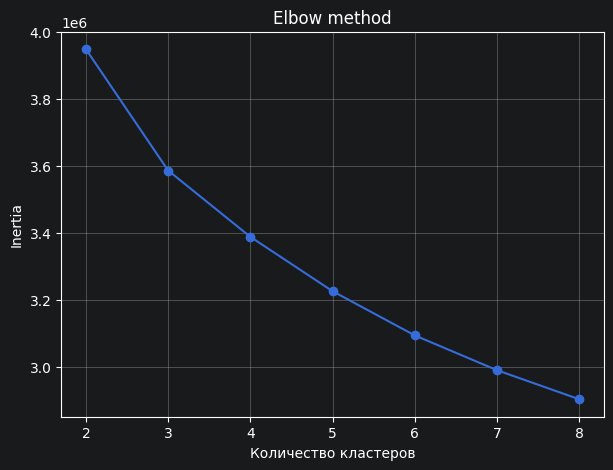

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(k_results_df["k"], k_results_df["inertia"], marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.grid()
plt.show()

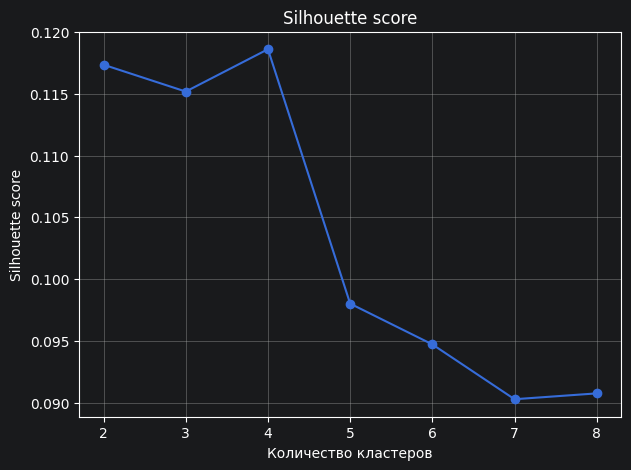

In [59]:
plt.figure(figsize=(7, 5))

plt.plot(k_results_df["k"], k_results_df["silhouette"], marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette score")
plt.title("Silhouette score")
plt.grid()
plt.show()

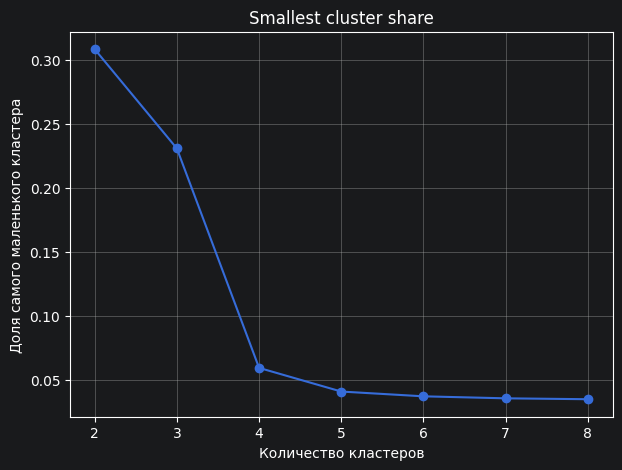

In [60]:
plt.figure(figsize=(7, 5))
plt.plot(k_results_df["k"], k_results_df["min_cluster_share"], marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Доля самого маленького кластера")
plt.title("Smallest cluster share")
plt.grid()
plt.show()

In [61]:
candidate_k = [2, 3, 4]
kmeans_models = {}

for k in candidate_k:
    print(f"Обучаем KMeans: k={k}")
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_kmeans_train_ready)
    kmeans_models[k] = model

Обучаем KMeans: k=2
Обучаем KMeans: k=3
Обучаем KMeans: k=4


In [62]:
def make_kmeans_features(model, X_ready, ids, k):
    clusters = model.predict(X_ready)
    distances = model.transform(X_ready)
    result = pd.DataFrame({
        "SK_ID_CURR": ids,
        f"KMEANS_{k}_CLUSTER": clusters
    })

    for cluster_num in range(k):
        result[f"KMEANS_{k}_DISTANCE_{cluster_num}"] = distances[:, cluster_num].astype("float32")
    return result

In [63]:
train_kmeans_parts = {}

for k in candidate_k:
    train_part = make_kmeans_features(
        model=kmeans_models[k],
        X_ready=X_kmeans_train_ready,
        ids=train_kmeans_ids,
        k=k
    )

    val_part = make_kmeans_features(
        model=kmeans_models[k],
        X_ready=X_kmeans_val_ready,
        ids=val_kmeans_ids,
        k=k
    )

    full_part = pd.concat(
        [
            train_part,
            val_part
        ],
        ignore_index=True
    )

    train_kmeans_parts[k] = (full_part)
    print(f"k={k}:", full_part.shape)

k=2: (307511, 4)
k=3: (307511, 5)
k=4: (307511, 6)


In [64]:
test_kmeans_parts = {}

for k in candidate_k:

    test_part = make_kmeans_features(
        model=kmeans_models[k],
        X_ready=X_kmeans_test_ready,
        ids=test_kmeans_ids,
        k=k
    )

    test_kmeans_parts[k] = (test_part)

    print(f"k={k}:", test_part.shape)

k=2: (48744, 4)
k=3: (48744, 5)
k=4: (48744, 6)


In [66]:
for k in candidate_k:

    train_path_kmeans = os.path.join(path_to_data, f"kmeans_k{k}_train.csv")
    test_path_kmeans = os.path.join(path_to_data, f"kmeans_k{k}_test.csv")

    train_kmeans_parts[k].to_csv(train_path_kmeans, index=False)
    test_kmeans_parts[k].to_csv(test_path_kmeans, index=False)
    print(f"k={k} сохранён")

k=2 сохранён
k=3 сохранён
k=4 сохранён


## trend-признаки
После проверки идеи на `installments_payments` тот же подход применяется ко всем историческим таблицам.
Общий принцип:
`TREND = statistic(recent window) - statistic(long window)`
Используются следующие сравнения:

| Источник | Короткое окно | Длинное окно |
|---|---:|---:|
| bureau | последние 3 / 5 кредита | последние 10 кредитов |
| bureau_balance | 3 / 6 месяцев | 12 месяцев |
| previous_application | последние 3 / 5 заявок | последние 10 заявок |
| POS_CASH_balance | 3 / 6 месяцев | 12 месяцев |
| installments_payments | 90 / 180 дней | 365 / 730 дней |
| credit_card_balance | 3 / 6 месяцев | 12 месяцев |

Всего в финальном датасете используется **86 trend-признаков**:
- bureau — 14;
- bureau_balance — 8;
- previous_application — 18;
- POS_CASH_balance — 12;
- installments_payments — 16;
- credit_card_balance — 18.
Цель этих признаков — дать модели информацию не только о текущем уровне показателя, но и о направлении изменения поведения клиента.

In [1]:
import os
import gc
import numpy as np
import pandas as pd

cache_dir = os.path.expanduser("~/PycharmProjects/home-credit-default-risk/data/processed/feature_cache")
processed_dir = os.path.dirname(cache_dir)

def add_trend_features(df, prefix, window_pairs, metrics):
    created = []

    for recent_window, long_window in window_pairs:

        for metric in metrics:

            recent_col = (
                f"{prefix}_LAST_"
                f"{recent_window}_"
                f"{metric}"
            )

            long_col = (
                f"{prefix}_LAST_"
                f"{long_window}_"
                f"{metric}"
            )

            if recent_col not in df.columns:
                raise KeyError(
                    f"Нет колонки: {recent_col}"
                )

            if long_col not in df.columns:
                raise KeyError(
                    f"Нет колонки: {long_col}"
                )

            trend_col = (
                f"{prefix}_TREND_"
                f"{recent_window}_"
                f"{long_window}_"
                f"{metric}"
            )

            df[trend_col] = (
                df[recent_col]
                - df[long_col]
            ).astype("float32")

            created.append(
                trend_col
            )

    return created

In [2]:
bureau_features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "bureau.pkl"
    )
)

bureau_features.index = (
    bureau_features.index.astype("int64")
)

bureau_trends = add_trend_features(
    df=bureau_features,

    prefix="BUREAU",

    window_pairs=[
        ("3", "10"),
        ("5", "10")
    ],

    metrics=[
        "AMT_CREDIT_SUM_median",
        "AMT_CREDIT_SUM_DEBT_median",
        "AMT_CREDIT_SUM_OVERDUE_median",
        "AMT_ANNUITY_median",

        "DEBT_TO_CREDIT_median",
        "OVERDUE_TO_CREDIT_median",

        "CREDIT_DAY_OVERDUE_max"
    ]
)

print(
    "Bureau trends:",
    len(bureau_trends)
)

Bureau trends: 14


In [3]:
bb_trends = add_trend_features(
    df=bureau_features,

    prefix="BB",

    window_pairs=[
        ("3M", "12M"),
        ("6M", "12M")
    ],

    metrics=[
        "IS_BB_OVERDUE_mean",
        "IS_BB_SEVERE_OVERDUE_mean",
        "BB_STATUS_LEVEL_mean",
        "BB_STATUS_LEVEL_max"
    ]
)

print(
    "Bureau balance trends:",
    len(bb_trends)
)

print(
    "Всего новых в bureau.pkl:",
    len(bureau_trends) + len(bb_trends)
)

Bureau balance trends: 8
Всего новых в bureau.pkl: 22


In [4]:
bureau_features.to_pickle(
    os.path.join(
        cache_dir,
        "bureau.pkl"
    )
)

print(
    "bureau.pkl:",
    bureau_features.shape
)

bureau.pkl: (305811, 232)


In [5]:
previous_features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "previous.pkl"
    )
)

previous_features.index = (
    previous_features.index.astype("int64")
)

previous_trends = add_trend_features(
    df=previous_features,

    prefix="PREV",

    window_pairs=[
        ("3", "10"),
        ("5", "10")
    ],

    metrics=[
        "AMT_APPLICATION_median",
        "AMT_CREDIT_median",
        "AMT_ANNUITY_median",
        "AMT_DOWN_PAYMENT_median",

        "CREDIT_TO_APPLICATION_median",

        "ESTIMATED_TOTAL_PAYMENT_median",
        "TOTAL_PAYMENT_TO_CREDIT_median",

        "PLANNED_DURATION_median",
        "ACTUAL_DURATION_median"
    ]
)

print(
    "Previous trends:",
    len(previous_trends)
)

previous_features.to_pickle(
    os.path.join(
        cache_dir,
        "previous.pkl"
    )
)

Previous trends: 18


In [6]:
pos_features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "pos.pkl"
    )
)

pos_features.index = (
    pos_features.index.astype("int64")
)

pos_trends = add_trend_features(
    df=pos_features,

    prefix="POS",

    window_pairs=[
        ("3M", "12M"),
        ("6M", "12M")
    ],

    metrics=[
        "SK_DPD_mean",
        "SK_DPD_DEF_mean",

        "POS_IS_OVERDUE_mean",
        "POS_IS_OVERDUE_DEF_mean",

        "POS_COMPLETION_RATIO_mean",

        "CNT_INSTALMENT_FUTURE_mean"
    ]
)

print(
    "POS trends:",
    len(pos_trends)
)

pos_features.to_pickle(
    os.path.join(
        cache_dir,
        "pos.pkl"
    )
)

POS trends: 12


In [7]:
cc_features = pd.read_pickle(
    os.path.join(
        cache_dir,
        "credit_card.pkl"
    )
)

cc_features.index = (
    cc_features.index.astype("int64")
)

cc_trends = add_trend_features(
    df=cc_features,

    prefix="CC",

    window_pairs=[
        ("3M", "12M"),
        ("6M", "12M")
    ],

    metrics=[
        "AMT_BALANCE_mean",

        "CC_UTILIZATION_mean",

        "AMT_DRAWINGS_CURRENT_mean",

        "AMT_PAYMENT_CURRENT_mean",

        "CC_PAYMENT_TO_MIN_mean",

        "SK_DPD_mean",
        "SK_DPD_DEF_mean",

        "CC_IS_OVERDUE_mean",
        "CC_IS_OVERDUE_DEF_mean"
    ]
)

print(
    "Credit card trends:",
    len(cc_trends)
)

cc_features.to_pickle(
    os.path.join(
        cache_dir,
        "credit_card.pkl"
    )
)

Credit card trends: 18


/tmp/ipykernel_23886/1667839771.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[trend_col] = (
/tmp/ipykernel_23886/1667839771.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[trend_col] = (
/tmp/ipykernel_23886/1667839771.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[trend_c

In [8]:
print(
    "Bureau:",
    len(bureau_trends)
)

print(
    "Bureau balance:",
    len(bb_trends)
)

print(
    "Previous:",
    len(previous_trends)
)

print(
    "POS:",
    len(pos_trends)
)

print(
    "Credit card:",
    len(cc_trends)
)

total_new_trends = (
    len(bureau_trends)
    + len(bb_trends)
    + len(previous_trends)
    + len(pos_trends)
    + len(cc_trends)
)

print(
    "Всего новых трендов:",
    total_new_trends
)

Bureau: 14
Bureau balance: 8
Previous: 18
POS: 12
Credit card: 18
Всего новых трендов: 70


In [9]:
for file_name, prefixes in [
    (
        "bureau.pkl",
        ["BUREAU_TREND_", "BB_TREND_"]
    ),
    (
        "previous.pkl",
        ["PREV_TREND_"]
    ),
    (
        "pos.pkl",
        ["POS_TREND_"]
    ),
    (
        "credit_card.pkl",
        ["CC_TREND_"]
    )
]:

    df = pd.read_pickle(
        os.path.join(
            cache_dir,
            file_name
        )
    )

    trend_cols_check = [
        col
        for col in df.columns
        if any(
            col.startswith(prefix)
            for prefix in prefixes
        )
    ]

    print(
        file_name,
        "| shape:",
        df.shape,
        "| trends:",
        len(trend_cols_check),
        "| duplicate cols:",
        df.columns.duplicated().sum(),
        "| index unique:",
        df.index.is_unique
    )

    del df
    gc.collect()

bureau.pkl | shape: (305811, 232) | trends: 22 | duplicate cols: 0 | index unique: True
previous.pkl | shape: (338857, 428) | trends: 18 | duplicate cols: 0 | index unique: True
pos.pkl | shape: (334586, 118) | trends: 12 | duplicate cols: 0 | index unique: True
credit_card.pkl | shape: (103558, 231) | trends: 18 | duplicate cols: 0 | index unique: True


In [10]:
trend_blocks = []

for file_name, prefixes in [
    (
        "bureau.pkl",
        ["BUREAU_TREND_", "BB_TREND_"]
    ),
    (
        "previous.pkl",
        ["PREV_TREND_"]
    ),
    (
        "pos.pkl",
        ["POS_TREND_"]
    ),
    (
        "credit_card.pkl",
        ["CC_TREND_"]
    )
]:

    df = pd.read_pickle(
        os.path.join(
            cache_dir,
            file_name
        )
    )

    cols = [
        col
        for col in df.columns
        if any(
            col.startswith(prefix)
            for prefix in prefixes
        )
    ]

    trend_blocks.append(
        df[cols].copy()
    )

    del df
    gc.collect()


all_new_trends = pd.concat(
    trend_blocks,
    axis=1
)

del trend_blocks
gc.collect()

all_new_trends.index = (
    all_new_trends.index.astype("int64")
)

print(
    all_new_trends.shape
)

print(
    "Columns:",
    len(all_new_trends.columns)
)

print(
    "Index unique:",
    all_new_trends.index.is_unique
)

print(
    "Duplicate columns:",
    all_new_trends.columns
    .duplicated()
    .sum()
)

print(
    "Inf:",
    np.isinf(
        all_new_trends.to_numpy()
    ).sum()
)

(353716, 70)
Columns: 70
Index unique: True
Duplicate columns: 0
Inf: 0


In [11]:
def patch_processed_csv(
        source_path,
        temp_path,
        trend_features
):

    existing_cols = (
        pd.read_csv(
            source_path,
            nrows=0
        )
        .columns
        .tolist()
    )

    cols_to_add = [
        col
        for col in trend_features.columns
        if col not in existing_cols
    ]

    print(
        "Новых колонок:",
        len(cols_to_add)
    )

    trend_to_add = (
        trend_features[
            cols_to_add
        ]
    )

    first_chunk = True
    total_rows = 0

    for chunk in pd.read_csv(
        source_path,
        chunksize=20000
    ):

        chunk["SK_ID_CURR"] = (
            chunk["SK_ID_CURR"]
            .astype("int64")
        )

        chunk = (
            chunk
            .set_index("SK_ID_CURR")
            .join(
                trend_to_add,
                how="left",
                validate="one_to_one"
            )
            .reset_index()
        )

        chunk.to_csv(
            temp_path,
            mode=(
                "w"
                if first_chunk
                else "a"
            ),
            header=first_chunk,
            index=False
        )

        total_rows += len(chunk)

        first_chunk = False

        print(
            "Записано:",
            total_rows
        )

        del chunk
        gc.collect()

    return cols_to_add

In [12]:
train_path = os.path.join(
    processed_dir,
    "application_train.csv"
)

train_tmp = os.path.join(
    processed_dir,
    "application_train_trends_tmp.csv"
)

train_added = patch_processed_csv(
    train_path,
    train_tmp,
    all_new_trends
)

Новых колонок: 70
Записано: 20000
Записано: 40000
Записано: 60000
Записано: 80000
Записано: 100000
Записано: 120000
Записано: 140000
Записано: 160000
Записано: 180000
Записано: 200000
Записано: 220000
Записано: 240000
Записано: 260000
Записано: 280000
Записано: 300000
Записано: 307511


In [13]:
test_path = os.path.join(
    processed_dir,
    "application_test.csv"
)

test_tmp = os.path.join(
    processed_dir,
    "application_test_trends_tmp.csv"
)

test_added = patch_processed_csv(
    test_path,
    test_tmp,
    all_new_trends
)

Новых колонок: 70
Записано: 20000
Записано: 40000
Записано: 48744


In [14]:
train_header = pd.read_csv(
    train_tmp,
    nrows=0
)

test_header = pd.read_csv(
    test_tmp,
    nrows=0
)

print(
    "Train columns:",
    len(train_header.columns)
)

print(
    "Test columns:",
    len(test_header.columns)
)

train_without_target = [
    col
    for col in train_header.columns
    if col != "TARGET"
]

print(
    "Train/Test совпадают:",
    train_without_target
    == test_header.columns.tolist()
)

print(
    "Разница:",
    set(train_header.columns)
    - set(test_header.columns)
)

Train columns: 1250
Test columns: 1249
Train/Test совпадают: True
Разница: {'TARGET'}


In [15]:
os.replace(
    train_tmp,
    train_path
)

os.replace(
    test_tmp,
    test_path
)

print(
    "Processed train/test обновлены"
)

Processed train/test обновлены


# Итог feature engineering
После завершения всех этапов получены:
- train: `307 511 × 1 250`;
- test: `48 744 × 1 249`;
- разница в одну колонку объясняется наличием `TARGET` только в train;
- 86 trend-признаков;
- отдельные KMeans-признаки для последующего сравнения в модели;
- уникальный `SK_ID_CURR`;
- отсутствие дубликатов колонок;
- одинаковый набор модельных признаков в train и test.
На этом этапе задача feature engineering завершена.
В следующем ноутбуке `04_model_tuning.ipynb` сравнивается влияние отдельных блоков признаков на ROC-AUC LightGBM, выбирается лучший вариант KMeans и выполняется подбор гиперпараметров через Optuna.